<a href="https://colab.research.google.com/github/ArwaFadaaq/Robust-Multimodal-Age-Verification-for-Online-Gaming-Chat/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Robust Multimodal Age Verification for Online Gaming Chat**

This notebook presents the data preparation and preprocessing pipeline for the **Robust Multimodal Age Verification for Online Gaming Chat** project. The goal is to develop an audio-based system that classifies speakers into **minor vs. adult** while remaining  
robust to spoofing attacks and noisy conditions in online gaming environments.

The workflow integrates multiple speech datasets, including Common Voice, MyST, and VoxCeleb, and organizes them into structured `train`, `val`, and `test` sets. It includes speaker-level splitting, audio preprocessing, and dataset balancing to support reliable and  
fair model training.

To enhance robustness, the pipeline incorporates **noise augmentation** at different levels, along with spoofing scenarios such as **text-to-speech (TTS)**, **voice conversion (VC)**, and **replay attacks**. Dedicated spoof target data is prepared for these scenarios, and balanced A/B splits are constructed to enable spoof-aware learning.

The final output is a clean, balanced, and diversified dataset suitable for training robust and generalizable models.

## **Section 1 — Environment Setup**

This section prepares the working environment for the pipeline. It includes
cloning the project repository from GitHub, installing the required
dependencies for preprocessing and model training, and mounting Google Drive
to enable persistent storage for datasets, intermediate artifacts, and final outputs.

The installed dependencies include `silero-vad` for voice activity detection,
as well as training-related libraries such as `transformers`, `peft`, and
`accelerate`.

In [ ]:
# GitHub username and repository name
USERNAME = "ArwaFadaaq"
REPO = "Robust-Multimodal-Age-Verification-for-Online-Gaming-Chat"

# Clone public repository
!git clone https://github.com/{USERNAME}/{REPO}.git

# Enter repository folder
%cd Robust-Multimodal-Age-Verification-for-Online-Gaming-Chat

Cloning into 'Robust-Multimodal-Age-Verification-for-Online-Gaming-Chat'...
remote: Enumerating objects: 1398, done.
remote: Counting objects: 100% (390/390), done.
remote: Compressing objects: 100% (242/242), done.
remote: Total 1398 (delta 325), reused 148 (delta 148), pack-reused 1008 (from 4)
Receiving objects: 100% (1398/1398), 2.65 MiB | 7.13 MiB/s, done.
Resolving deltas: 100% (816/816), done.
/content/Robust-Multimodal-Age-Verification-for-Online-Gaming-Chat/Robust-Multimodal-Age-Verification-for-Online-Gaming-Chat


In [ ]:
# Install Silero VAD for voice activity detection
!pip install silero-vad

# Training dependencies (LoRA + transformers)
!pip install -U peft transformers accelerate

!pip uninstall -y torchao
!pip install torchao --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 116.5 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 64.9 MB/s eta 0:00:00


In [ ]:
# Mount Google Drive to access datasets and store processed outputs
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## **Section 2 — Module Imports**

This section imports standard Python libraries such as `os` and `pandas` for file handling and data manipulation, in addition to project-specific modules.  Local modules including `data_preparation`, `speaker_split_utils`, and `preprocessing` are imported to support the data pipeline, speaker-level splitting, and audio preprocessing workflow.

In [ ]:
# Standard libraries for file handling and data manipulation
import os
import pandas as pd

# Project-specific modules for data preparation and analysis
from data_preparation import (
    build_file_manifest,
    load_manifests,
    add_gender_from_splits,
    summarize_segment_distribution,
    filter_and_cap_segments,
    save_final_splits
)

# Runtime/local data utilities
from local_data_utils import (
    update_manifest_paths,
    load_archive_to_local,
    create_tar_from_manifests,
    copy_file
)

# Utilities for speaker-level splitting
from speaker_split_utils import run_speaker_split_pipeline, split_half

# Preprocessing pipeline and configuration
from preprocessing import run_pipeline, HOP_TRAIN_SEC

# Training and evaluation functions
from wavlm_lora_pipeline import (
    train_model,
    evaluate_model,
    compute_train_stats,
    summarize_metrics_for_filters,

    REAL_AGE_FILTERS,
    SPOOF_SUBTYPE_FILTERS,
    CROSS_AGE_FILTERS,

    ENGINE_FILTERS_B2,
    ENGINE_FILTERS_D1,
    ENGINE_FILTERS_D2,

)

# Gaussian noise augmentation
from gaussian_noise import train_gaussian_noise_transform

---
## **Section 3 — Speaker-Level Stratified Split (Main Pools)**

In this section, speakers are partitioned at the speaker level such that each speaker is assigned entirely to a single split. **No speaker appears in more than one split**, ensuring that data leakage between training, validation, and testing sets is prevented.

The dataset is divided as follows:
- **Train**: 70% of speakers  
- **Validation (Val)**: 15% of speakers  
- **Test**: 15% of speakers  

The stratified split is applied to the following main pools:
- `adult_real_candidates`  
- `adult_spoof_targets`  
- `minor_real_candidates`  
- `minor_spoof_targets`  

In addition, a separate **backup pool** derived from the Common Voice dataset is maintained. This pool is used when needed for fallback or data balancing purposes.

In [ ]:
# ─── Speaker-Level Stratified Split ──────────────────────────────────────────
base = "/content/drive/MyDrive/age verification/data/final_inventory/pools"

input_files = {
    "adult_real_candidates": f"{base}/adult_real_candidates.csv",
    "adult_spoof_targets":   f"{base}/adult_spoof_targets.csv",
    "minor_real_candidates": f"{base}/minor_real_candidates.csv",
    "minor_spoof_targets":   f"{base}/minor_spoof_targets.csv",
}

run_speaker_split_pipeline(
    input_files=input_files,
    output_dir="/content/drive/MyDrive/age verification/processed/splits/",
    train_ratio=0.70,
    val_ratio=0.15,
    seed=42
)


Processing: adult_real_candidates

Speaker counts:
train: 1229 (69.91%)
val: 262 (14.90%)
test: 267 (15.19%)

Processing: adult_spoof_targets

Speaker counts:
train: 463 (69.73%)
val: 99 (14.91%)
test: 102 (15.36%)

Processing: minor_real_candidates

Speaker counts:
train: 1230 (69.97%)
val: 264 (15.02%)
test: 264 (15.02%)

Processing: minor_spoof_targets

Speaker counts:
train: 464 (69.88%)
val: 99 (14.91%)
test: 101 (15.21%)


---
## **Section 4 — Build Unified File Manifest**

This section constructs a unified file manifest by combining the speaker-level split CSV files with metadata from multiple datasets, including Common Voice, MyST, and VoxCeleb.  
All information is consolidated into a single file, `file_manifest.csv`.

For each pool, speakers are matched to their corresponding audio files, and a unique identifier (`file_id`) is assigned to each file.

Each row in the manifest represents a single audio file with the following attributes:

- `file_id`: Unique file identifier  
- `speaker_id`: Speaker identifier  
- `dataset`: Source dataset (`common_voice`, `myst`, `voxceleb`)  
- `pool`: Pool name (e.g., `adult_real_candidates`)  
- `split`: Data split label (`train`, `val`, `test`)  
- `path`: Absolute file path  
- `raw_duration_sec`: Audio duration before preprocessing (in seconds)

In [ ]:
# ─── Build Unified File Manifest ─────────────────────────

# Paths to speaker-level split files (role inventories)
role_inventory_paths = [
    "/content/drive/MyDrive/age verification/processed/splits/adult_real_candidates_split.csv",
    "/content/drive/MyDrive/age verification/processed/splits/minor_real_candidates_split.csv",
    "/content/drive/MyDrive/age verification/processed/splits/adult_spoof_targets_split.csv",
    "/content/drive/MyDrive/age verification/processed/splits/minor_spoof_targets_split.csv",
]

# Metadata sources for each dataset
metadata_paths = {
    "common_voice": "/content/drive/MyDrive/age verification/data/common_voice/data_extraction/cv_extracted_final_metadata.csv",
    "myst": "/content/drive/MyDrive/age verification/data/myst/myst_file_metadata.csv",
    "voxceleb": "/content/drive/MyDrive/age verification/data/voxceleb2/metadata/voxceleb_segment_metadata.csv",
}

# Construct the unified file manifest
file_manifest = build_file_manifest(
    role_inventory_paths=role_inventory_paths,
    metadata_paths=metadata_paths,
    out_path="/content/drive/MyDrive/age verification/processed/manifest/file_manifest.csv",
)

Total speakers: 4844
Total files:    286907
Saved: /content/drive/MyDrive/age verification/processed/manifest/file_manifest.csv


---
## **Section 5 — Preprocessing Pipeline**

This section describes the audio preprocessing pipeline applied to the dataset. The preprocessing stage prepares raw audio files, ensures consistent formatting, and generates suitable audio segments for subsequent tasks.

The pipeline is applied differently depending on the data type (**real candidates** vs. **spoof targets**). Real candidates are preprocessed to generate **training-ready input segments**, whereas spoof targets are processed to prepare audio files for **spoof generation and transformation**.

### **Section 5.1 — Real Candidates**

This section loads the unified file manifest and filters it to include only the `real_candidates` pool. The audio preprocessing pipeline is then applied to all selected datasets.

The preprocessing configuration is defined as follows:
- **Train**: uses a sliding window with `hop_sec = 1.5` seconds to enable data augmentation (overlapping segments)  
- **Validation (Val) / Test**: no overlap is applied (`hop_sec = None`)  
- **save_mode = "segments"**: each audio file is segmented into fixed-length (3-second) audio clips and saved individually

In [ ]:
# Load the unified file manifest
file_list = pd.read_csv(
    "/content/drive/MyDrive/age verification/processed/manifest/file_manifest.csv",
    dtype={"speaker_id": str},   # Preserve speaker IDs as strings (avoid losing leading zeros)
    low_memory=False             # Ensure consistent dtype inference
)

# Filter to include only real candidate pools
file_list_real = file_list[
    file_list["pool"].str.contains("real_candidates", na=False)
].copy()

# ─── Output Paths (Real Candidates) ─────────────────────────

# Directory for saving processed audio segments
processed_dir_real = "/content/drive/MyDrive/age verification/processed/data/real_candidates"

# Directory for saving segment-level manifests
manifest_dir_real  = "/content/drive/MyDrive/age verification/processed/manifest/real_candidates"

In [ ]:
# ─── Process Real Candidates: Common Voice ─────────────────────────────
# Common Voice includes both adult and minor speakers.

for split in ["train", "val", "test"]:
    print("\n" + "=" * 60)
    print(f"Processing DATASET = common_voice | SPLIT = {split} | POOL = real_candidates")
    print("=" * 60)

    # Use overlapping segments for training only; validation/test use non-overlapping segments
    hop = HOP_TRAIN_SEC if split == "train" else None

    run_pipeline(
        file_list=file_list_real,
        dataset="common_voice",
        split=split,
        processed_dir=processed_dir_real,
        manifest_dir=manifest_dir_real,
        hop_sec=hop,
        save_mode="segments"
    )


Processing DATASET = common_voice | SPLIT = train | POOL = real_candidates
Resuming — 10625 files done, 12720 segments found
Files remaining: 0
cv_train already processed.

Processing DATASET = common_voice | SPLIT = val | POOL = real_candidates
Resuming — 2120 files done, 1785 segments found
Files remaining: 0
cv_val already processed.

Processing DATASET = common_voice | SPLIT = test | POOL = real_candidates
Resuming — 2449 files done, 2039 segments found
Files remaining: 0
cv_test already processed.


In [ ]:
# ─── Process Real Candidates: MyST ─────────────────────────────
# MyST dataset contains child speech (minor class only)

for split in ["train", "val", "test"]:
    print("\n" + "=" * 60)
    print(f"Processing DATASET = myst | SPLIT = {split} | POOL = real_candidates")
    print("=" * 60)

    # Use overlapping segments for training; no overlap for validation/test
    hop = HOP_TRAIN_SEC if split == "train" else None

    run_pipeline(
        file_list=file_list_real,
        dataset="myst",
        split=split,
        processed_dir=processed_dir_real,
        manifest_dir=manifest_dir_real,
        hop_sec=hop,
        save_mode="segments"
    )


Processing DATASET = myst | SPLIT = train | POOL = real_candidates
Resuming — 41231 files done, 55041 segments found
Files remaining: 0
myst_train already processed.

Processing DATASET = myst | SPLIT = val | POOL = real_candidates
Resuming — 8331 files done, 6958 segments found
Files remaining: 0
myst_val already processed.

Processing DATASET = myst | SPLIT = test | POOL = real_candidates
Resuming — 9446 files done, 7674 segments found
Files remaining: 0
myst_test already processed.


In [ ]:
# ─── Process Real Candidates: VoxCeleb ─────────────────────────────
# VoxCeleb dataset contains adult speech (adult class only)

for split in ["train", "val", "test"]:
    print("\n" + "=" * 60)
    print(f"Processing DATASET = voxceleb | SPLIT = {split} | POOL = real_candidates")
    print("=" * 60)

    # Use overlapping segments for training; no overlap for validation/test
    hop = HOP_TRAIN_SEC if split == "train" else None

    run_pipeline(
        file_list=file_list_real,
        dataset="voxceleb",
        split=split,
        processed_dir=processed_dir_real,
        manifest_dir=manifest_dir_real,
        hop_sec=hop,
        save_mode="segments"
    )


Processing DATASET = voxceleb | SPLIT = train | POOL = real_candidates
Resuming — 4382 files done, 10664 segments found
Files remaining: 0
vox_train already processed.

Processing DATASET = voxceleb | SPLIT = val | POOL = real_candidates
Resuming — 941 files done, 1419 segments found
Files remaining: 0
vox_val already processed.

Processing DATASET = voxceleb | SPLIT = test | POOL = real_candidates
Resuming — 865 files done, 1342 segments found
Files remaining: 0
vox_test already processed.


### **Section 5.2 — Spoof Targets**

This subsection processes the `spoof_targets` pool across Common Voice, MyST, and VoxCeleb. These speakers are reserved for **text-to-speech (TTS)** and **voice conversion (VC)** generation, where their recordings are used as reference audio rather than direct model training input.

Unlike the real candidates pool, spoof target recordings are preserved as full audio files to retain speaker-specific characteristics required for spoof synthesis. During preprocessing, the standard audio pipeline is applied, including converting recordings to mono and resampling them to 16 kHz. However, no segmentation is performed for this pool, and each recording is saved as a complete audio file.

The preprocessing pipeline is executed using:
- `hop_sec = None`: disables segmentation
- `save_mode = "files"`: preserves full recordings



In [ ]:
# Filter to include only spoof target pools
file_list_spoof_targets = file_list[
    file_list["pool"].str.contains("spoof_targets", na=False)
].copy()

# ─── Output Paths (Spoof Targets) ─────────────────────────

# Directory for saving processed audio files (full recordings)
processed_dir_spoof = "/content/drive/MyDrive/age verification/processed/data/spoof_targets"

# Directory for saving file-level manifests
manifest_dir_spoof  = "/content/drive/MyDrive/age verification/processed/manifest/spoof_targets"

In [ ]:
# ─── Process Spoof Targets: MyST ─────────────────────────

for split in ["train", "val", "test"]:
    print("\n" + "=" * 60)
    print(f"Processing DATASET = myst | SPLIT = {split} | POOL = spoof_targets")
    print("=" * 60)

    run_pipeline(
        file_list=file_list_spoof_targets,
        dataset="myst",
        split=split,
        processed_dir=processed_dir_spoof,
        manifest_dir=manifest_dir_spoof,
        hop_sec=None,
        save_mode="files"
    )


Processing DATASET = myst | SPLIT = train | POOL = spoof_targets
Resuming — 60936 files done, 0 segments found
Files remaining: 0
myst_train already processed.

Processing DATASET = myst | SPLIT = val | POOL = spoof_targets
Resuming — 13647 files done, 0 segments found
Files remaining: 0
myst_val already processed.

Processing DATASET = myst | SPLIT = test | POOL = spoof_targets
Resuming — 12485 files done, 0 segments found
Files remaining: 0
myst_test already processed.


In [ ]:
# ─── Process Spoof Targets: Common Voice ─────────────────────────

for split in ["train", "val", "test"]:
    print("\n" + "=" * 60)
    print(f"Processing DATASET = common_voice | SPLIT = {split} | POOL = spoof_targets")
    print("=" * 60)

    run_pipeline(
        file_list=file_list_spoof_targets,
        dataset="common_voice",
        split=split,
        processed_dir=processed_dir_spoof,
        manifest_dir=manifest_dir_spoof,
        hop_sec=None,
        save_mode="files"
    )


Processing DATASET = common_voice | SPLIT = train | POOL = spoof_targets
Resuming — 78108 files done, 0 segments found
Files remaining: 0
cv_train already processed.

Processing DATASET = common_voice | SPLIT = val | POOL = spoof_targets
Resuming — 15821 files done, 0 segments found
Files remaining: 0
cv_val already processed.

Processing DATASET = common_voice | SPLIT = test | POOL = spoof_targets
Resuming — 8429 files done, 0 segments found
Files remaining: 0
cv_test already processed.


In [ ]:
# ─── Process Spoof Targets: VoxCeleb ─────────────────────────

for split in ["train", "val", "test"]:
    print("\n" + "=" * 60)
    print(f"Processing DATASET = voxceleb | SPLIT = {split} | POOL = spoof_targets")
    print("=" * 60)

    run_pipeline(
        file_list=file_list_spoof_targets,
        dataset="voxceleb",
        split=split,
        processed_dir=processed_dir_spoof,
        manifest_dir=manifest_dir_spoof,
        hop_sec=None,
        save_mode="files"
    )


Processing DATASET = voxceleb | SPLIT = train | POOL = spoof_targets
Resuming — 12182 files done, 0 segments found
Files remaining: 0
vox_train already processed.

Processing DATASET = voxceleb | SPLIT = val | POOL = spoof_targets
Resuming — 2147 files done, 0 segments found
Files remaining: 0
vox_val already processed.

Processing DATASET = voxceleb | SPLIT = test | POOL = spoof_targets
Resuming — 2762 files done, 0 segments found
Files remaining: 0
vox_test already processed.


After preprocessing, an external VAD evaluation file is used to filter the spoof target recordings. Only recordings that successfully pass the VAD validation process and contain at least 7 seconds of detected speech are retained for spoof generation.

The filtering step is defined as follows:
- `vad_status = "success"`
- `speech_duration_sec >= 7`

Finally, the filtered files are linked with speaker metadata such as gender, merged into unified manifests, and then separated back into train, validation, and test sets to maintain consistency with the overall pipeline structure.

In [ ]:
# ─── Load Combined Spoof Manifest + VAD Results ───────────

combined_manifest_path = (
    "/content/drive/MyDrive/age verification/"
    "processed/manifest/spoof_targets/ge3/"
    "file_manifest_spoof_targets_ge3_with_vad.csv"
)

file_manifest = pd.read_csv(combined_manifest_path, low_memory=False)

print(file_manifest.shape)

(174975, 15)


In [ ]:
# ─── Add Speaker Gender Metadata ─────────────────────────

role_inventory_paths_gender = [
    "/content/drive/MyDrive/age verification/processed/splits/adult_spoof_targets_split.csv",
    "/content/drive/MyDrive/age verification/processed/splits/minor_spoof_targets_split.csv",
]

file_manifest = add_gender_from_splits(
    manifest_df=file_manifest,
    role_inventory_paths=role_inventory_paths_gender
)

In [ ]:
# ─── Keep Only Valid Files For Spoofing ───────────────────

filtered_manifest = file_manifest[
    (file_manifest["vad_status"] == "success")
    &
    (file_manifest["speech_duration_sec"] >= 7)
].copy()

print("Original shape :", file_manifest.shape)
print("Filtered shape :", filtered_manifest.shape)

display(
    filtered_manifest[
        ["file_id", "dataset", "split",
         "speech_duration_sec", "vad_status"]
    ].head()
)

Original shape : (174975, 16)
Filtered shape : (32171, 16)


,file_id,dataset,split,speech_duration_sec,vad_status
45,common_voice_551d5ea36eb46269c7a7710255ff0cab3...,common_voice,test,7.13,success
113,common_voice_21714a0fe5ff1ccc074e4a9977894a4b3...,common_voice,test,7.76,success
1087,common_voice_bf1e2dc5b5bc3f558bbd8486cc37c2e99...,common_voice,test,7.23,success
1244,common_voice_e62191545c734494b9c764f2b0f43deef...,common_voice,test,7.09,success
1264,common_voice_e766110ede563e8b2f4abd8155e29f724...,common_voice,test,7.10,success


In [ ]:
# ─── Save Final Spoof Target Splits ───────────────────────

out_dir = "/content/drive/MyDrive/age verification/processed/manifest/spoof_targets_splits"

final_spoof_splits = save_final_splits(
    manifest_df=filtered_manifest,
    out_dir=out_dir,
    dataset_name="spoof_targets"
)

Saved to: /content/drive/MyDrive/age verification/processed/manifest/spoof_targets_splits/train_spoof_targets.csv
Saved to: /content/drive/MyDrive/age verification/processed/manifest/spoof_targets_splits/val_spoof_targets.csv
Saved to: /content/drive/MyDrive/age verification/processed/manifest/spoof_targets_splits/test_spoof_targets.csv


---
## **Section 6 — Backup Data Processing**

This section applies the same preprocessing pipeline to a backup pool derived exclusively from the **Common Voice** dataset.  
The backup data is maintained separately and is used when necessary for fallback scenarios or to address data imbalance, ensuring robustness and consistency across different data conditions.

The processing pipeline involves:
- **Speaker-level splitting**, where speakers are assigned to disjoint splits  
- **Unified file manifest construction**, where metadata and file paths are consolidated  
- **Audio preprocessing**, where the audio data is prepared for further use

In [ ]:
# ─── Speaker-Level Stratified Split (Backup — Common Voice Only) ─────────────

# Base directory for backup pool CSV files
base = "/content/drive/MyDrive/age verification/data/final_inventory/pools"

# Output directory for generated split files
out_dir = "/content/drive/MyDrive/age verification/processed/splits"

# Input files for backup pools (Common Voice only)
input_files = {
    "adult_backup": f"{base}/adult_backup_cv.csv",
    "minor_backup": f"{base}/minor_backup_cv.csv",
}

# Apply speaker-level stratified split (train/val/test)
run_speaker_split_pipeline(
    input_files=input_files,
    output_dir=out_dir,
    train_ratio=0.70,
    val_ratio=0.15,
    seed=42
)

# Rename outputs to explicitly indicate Common Voice (cv)
os.rename(f"{out_dir}/adult_backup_split.csv", f"{out_dir}/adult_backup_cv_split.csv")
os.rename(f"{out_dir}/minor_backup_split.csv", f"{out_dir}/minor_backup_cv_split.csv")

print("\nRenamed successfully.")


Processing: adult_backup

Speaker counts:
train: 226 (68.69%)
val: 52 (15.81%)
test: 51 (15.50%)

Processing: minor_backup

Speaker counts:
train: 231 (70.21%)
val: 49 (14.89%)
test: 49 (14.89%)

Renamed successfully.


In [ ]:
# ─── Build CV Backup File Manifest ─────────────────────────

# Paths to speaker-level split files for the backup pool (Common Voice only)
role_inventory_paths = [
    "/content/drive/MyDrive/age verification/processed/splits/adult_backup_cv_split.csv",
    "/content/drive/MyDrive/age verification/processed/splits/minor_backup_cv_split.csv",
]

# Metadata source for Common Voice backup data
metadata_paths = {
    "common_voice": "/content/drive/MyDrive/age verification/data/common_voice/data_extraction_cv_backup/cv_backup_extracted_metadata.csv",
}

# Construct the backup file manifest
file_manifest = build_file_manifest(
    role_inventory_paths=role_inventory_paths,
    metadata_paths=metadata_paths,
    out_path="/content/drive/MyDrive/age verification/processed/manifest/cv_backup_file_manifest.csv",
)

Total speakers: 658
Total files:    83129
Saved: /content/drive/MyDrive/age verification/processed/manifest/cv_backup_file_manifest.csv


In [ ]:
# ─── Process Backup: Common Voice ─────────────────────────────
# Common Voice backup pool (used for fallback and data balancing)

file_list = pd.read_csv(
    "/content/drive/MyDrive/age verification/processed/manifest/cv_backup_file_manifest.csv",
    dtype={"speaker_id": str},
    low_memory=False
)

# Keep only backup pools
file_list_backup = file_list[
    file_list["pool"].str.contains("backup", na=False)
].copy()

# ─── Paths (backup) ────────────────────────────────────────
processed_dir_backup = "/content/drive/MyDrive/age verification/processed/data/cv_backup"
manifest_dir_backup  = "/content/drive/MyDrive/age verification/processed/manifest/cv_backup"

for split in ["train", "val", "test"]:
    print("\n" + "=" * 60)
    print(f"Processing DATASET = common_voice | SPLIT = {split} | POOL = backup")
    print("=" * 60)

    # Use overlapping segments for training only; validation/test use non-overlapping segments
    hop = HOP_TRAIN_SEC if split == "train" else None

    run_pipeline(
        file_list=file_list_backup,
        dataset="common_voice",
        split=split,
        processed_dir=processed_dir_backup,
        manifest_dir=manifest_dir_backup,
        hop_sec=hop,
        save_mode="segments"
    )


Processing DATASET = common_voice | SPLIT = train | POOL = backup
Resuming — 52602 files done, 57126 segments found
Files remaining: 0
cv_train already processed.

Processing DATASET = common_voice | SPLIT = val | POOL = backup
Resuming — 20379 files done, 17873 segments found
Files remaining: 0
cv_val already processed.

Processing DATASET = common_voice | SPLIT = test | POOL = backup
Resuming — 10148 files done, 8026 segments found
Files remaining: 0
cv_test already processed.


---
## **Section 7 — Clean Dataset Preparation**

This section prepares the final clean dataset by combining segment manifests from the `real_candidates` and `backup` pools. Speaker metadata (e.g., gender) is incorporated to support distribution analysis and balancing checks.

Filtering and capping are applied to remove low-quality segments and reduce imbalance. The final clean `train`, `val`, and `test` splits are then generated.

Additionally, condition-related columns (`authenticity`, `spoof_type`, `noise_type`, `SNR_db`) are added with default values to explicitly indicate that all samples are real, non-spoofed, and noise-free.

In [ ]:
# ─── Load Segment Manifests (Real + Backup) ─────────────────

real_manifest_dir   = "/content/drive/MyDrive/age verification/processed/manifest/real_candidates"
backup_manifest_dir = "/content/drive/MyDrive/age verification/processed/manifest/cv_backup"

segment_manifest = load_manifests(
    manifest_dirs=[real_manifest_dir, backup_manifest_dir],
    manifest_type="segment"
)

In [ ]:
# ─── Add Speaker Gender Metadata ─────────────────────────

role_inventory_paths_gender = [
    "/content/drive/MyDrive/age verification/processed/splits/adult_real_candidates_split.csv",
    "/content/drive/MyDrive/age verification/processed/splits/minor_real_candidates_split.csv",
    "/content/drive/MyDrive/age verification/processed/splits/adult_backup_cv_split.csv",
    "/content/drive/MyDrive/age verification/processed/splits/minor_backup_cv_split.csv",
]

segment_manifest = add_gender_from_splits(
    manifest_df=segment_manifest,
    role_inventory_paths=role_inventory_paths_gender
)

Segments per speaker summary:
count    4141.000000
mean       44.111809
std       180.386728
min         1.000000
25%         6.000000
50%        13.000000
75%        33.000000
90%       112.000000
95%       175.000000
max      8144.000000
Name: num_segments, dtype: float64


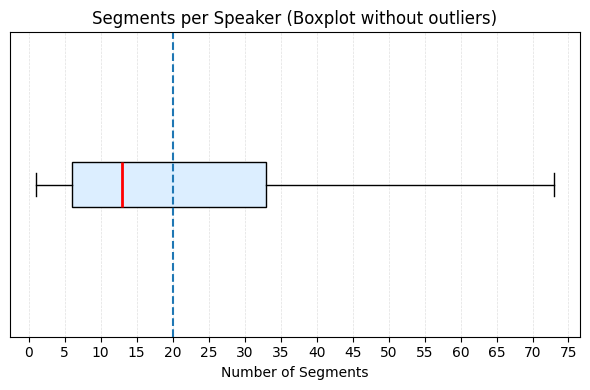

In [ ]:
# ─── Analyze Segment Distribution (Before Filtering/Capping) ─────────

speaker_stats = summarize_segment_distribution(
    segment_manifest,
    plot=True,
    cap_line=20
)

The distribution of segments per speaker shows a clear **imbalance**, where most speakers have a relatively small number of segments (median = 13), while a few speakers have significantly higher counts. This is reflected in the high variance and the presence of a **long tail** in the distribution.

To address this imbalance, a maximum cap of **20 segments per speaker** is applied, as indicated by the dashed line. This reduces the influence of high-resource speakers and promotes a more **balanced dataset** for training.

In [ ]:
# ─── Filter and Cap Segments ─────────────────────────

capped_manifest = filter_and_cap_segments(
    segment_manifest,
    min_segments=8,
    max_segments=20,
    seed=42
)

Original segment manifest:
Segments: 182667
Speakers: 4141

After removing clipped segments:
Segments: 166448
Speakers: 4127

After removing speakers with < 8 clean segments:
Segments: 160542
Speakers: 2790

After capping to max 20 clean segments per speaker:
Segments: 46226
Speakers: 2790

Clean segments per speaker after filtering and cap:
count    2790.000000
mean       16.568459
std         4.382583
min         8.000000
25%        13.000000
50%        20.000000
75%        20.000000
max        20.000000
dtype: float64


The dataset was filtered and balanced, reducing it from **182,667 segments (4,141 speakers)** to **46,226 segments (2,790 speakers)** after removing clipped segments, excluding speakers with fewer than 8 segments, and applying a cap of 20 segments per speaker.

The distribution is more balanced, with an average of approximately 16.6 segments per speaker within a range of 8 to 20 segments.

In [ ]:
# ─── Save Final Clean Splits ─────────────────────────

out_dir = "/content/drive/MyDrive/age verification/processed/manifest/real_clean_splits"

final_splits = save_final_splits(
    manifest_df=capped_manifest,
    out_dir=out_dir,
    dataset_name="real_clean"
)


TRAIN_REAL_CLEAN


,dataset_source,mapped_age_class,total_segments,total_speakers
0,common_voice,adult,8313,517
1,common_voice,minor,9450,598
2,myst,minor,8711,451
3,voxceleb,adult,8237,502


Saved to: /content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/train_real_clean.csv

VAL_REAL_CLEAN


,dataset_source,mapped_age_class,total_segments,total_speakers
0,common_voice,adult,1353,84
1,common_voice,minor,1499,100
2,myst,minor,1719,91
3,voxceleb,adult,1186,87


Saved to: /content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/val_real_clean.csv

TEST_REAL_CLEAN


,dataset_source,mapped_age_class,total_segments,total_speakers
0,common_voice,adult,1460,93
1,common_voice,minor,1518,100
2,myst,minor,1745,92
3,voxceleb,adult,1035,75


Saved to: /content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/test_real_clean.csv


In [ ]:
base_dir = "/content/drive/MyDrive/age verification/processed/manifest/real_clean_splits"

for f in ["train_real_clean.csv", "val_real_clean.csv", "test_real_clean.csv"]:
    path = f"{base_dir}/{f}"
    df = pd.read_csv(path)

    # add default clean labels
    df[["authenticity", "spoof_type"]] = ["real", "none"]

    df.to_csv(path, index=False)
    print(f"Updated: {f}")

Updated: train_real_clean.csv
Updated: val_real_clean.csv
Updated: test_real_clean.csv


---
## **Section 8 — Balanced Clean/Spoof Split**

The `train`, `val`, and `test` sets are each split into two balanced subsets: `real_only_clean` and `spoof_source_clean`. The `real_only_clean` subset remains unchanged with no spoofing applied, while the `spoof_source_clean` subset is used for spoof generation. Both subsets are used for model training.

In [ ]:
# ─── Execute balanced A/B split for train, validation, and test datasets ───
import pandas as pd

SPLIT_DIR = "/content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/final_split"
train_df = pd.read_csv("/content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/train_real_clean.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/val_real_clean.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/test_real_clean.csv")

train_real_only_clean, train_spoof_source_clean = split_half(train_df, "train", SPLIT_DIR)
valid_real_only_clean, valid_spoof_source_clean = split_half(val_df,   "val",   SPLIT_DIR)
test_real_clean, ttest_spoof_source_clean = split_half(test_df,  "test",  SPLIT_DIR)

print("Saved to:", SPLIT_DIR)

train: real_only_clean=17354, spoof_source_clean=17357, diff=3, overlap=0
val: real_only_clean=2877, spoof_source_clean=2880, diff=3, overlap=0
test: real_only_clean=2882, spoof_source_clean=2876, diff=6, overlap=0
Saved to: /content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/final_split


## **Section 9 — Local Data Setup (Runtime Optimization)**

To reduce Google Drive I/O overhead and improve training speed, reusable tar archives were created using only the audio files referenced in the experiment manifests. Before training, the required archive is copied to the local runtime (`/content`) and extracted locally for faster audio access. Manifest paths are then automatically updated to point to the local runtime directory through a unified `local_path` column used by the training and evaluation pipelines.

**Create Reusable Real Data Archive**

The following archive contains only the real audio files referenced in the training and validation manifests, including clean and noisy validation subsets. This reduces unnecessary storage usage and improves local runtime loading efficiency during real-only experiments.

In [ ]:
# ─── Create Reusable Archive ─────────────────────────

csv_inputs = {
    "seg_path": [

        # clean
        "/content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/train_real_clean.csv",
        "/content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/val_real_clean.csv"
    ],

    "seg_noisy_path": [

        # noisy validation
        "/content/drive/MyDrive/age verification/processed/manifest/gaussian_noise/valid_real_only_aug.csv",
        "/content/drive/MyDrive/age verification/processed/manifest/gaussian_noise/valid_spoof_source_aug.csv"
    ]
}

base_dirs = [
    "/content/drive/MyDrive/age verification/processed/data"
]

_ = create_tar_from_manifests(
    csv_inputs=csv_inputs,
    base_dirs=base_dirs,
    tar_path="/content/real_train_valid.tar"
)

Resuming existing archive: 46,225 files already added

Created archive → /content/real_train_valid.tar


In [ ]:
# ─── Save Archive to Drive ─────────────────────────

_ = copy_file(
    src="/content/real_train_valid.tar",
    dst="/content/drive/MyDrive/age verification/processed/data/real_train_valid.tar"
)

Copied file:
  From → /content/real_train_valid.tar
  To   → /content/drive/MyDrive/age verification/processed/data/real_train_valid.tar


**Create Reusable Spoof Archive**

The following archive contains only the spoofed audio files referenced in the training and validation manifests. This reduces unnecessary storage and improves runtime loading efficiency during spoof-aware experiments.

In [ ]:
# ─── Create Reusable Archive — Spoof Train/Valid ─────────────────────────

csv_inputs = {
    "spoofed_seg_path": [
        "/content/drive/MyDrive/age verification/spoofing/manifest/train_spoof_set1_clean.csv",
        "/content/drive/MyDrive/age verification/spoofing/manifest/train_spoof_set2_clean.csv",
        "/content/drive/MyDrive/age verification/spoofing/manifest/train_spoof_set3_clean.csv"
    ],

    "seg_noisy_path": [
        "/content/drive/MyDrive/age verification/spoofing/manifest/gaussian_noise/valid_spoof_set1_aug.csv",
        "/content/drive/MyDrive/age verification/spoofing/manifest/gaussian_noise/valid_spoof_set2_aug.csv",
        "/content/drive/MyDrive/age verification/spoofing/manifest/gaussian_noise/valid_spoof_set3_aug.csv"
    ]
}

base_dirs = [
    "/content/drive/MyDrive/age verification/spoofing/data"
]

_ = create_tar_from_manifests(
    csv_inputs=csv_inputs,
    base_dirs=base_dirs,
    tar_path="/content/spoof_train_valid.tar"
)

Creating new archive
Added 60,711 files from → /content/drive/MyDrive/age verification/spoofing/data

Created archive → /content/spoof_train_valid.tar


In [ ]:
# ─── Save Archive to Drive ─────────────────────────

_ = copy_file(
    src="/content/spoof_train_valid.tar",
    dst="/content/drive/MyDrive/age verification/spoofing/data/spoof_train_valid.tar"
)

Copied file:
  From → /content/spoof_train_valid.tar
  To   → /content/drive/MyDrive/age verification/spoofing/data/spoof_train_valid.tar


**Create Reusable Test Archive**

The following archive contains all audio files referenced in the unified test manifest, including both real and spoofed samples.  
 The archive is used to reduce repeated Google Drive I/O operations and improve runtime loading efficiency during final evaluation  
  across all experiments.

In [ ]:
# ─── Create Test Archive from Unified Manifest ─────────────────────────

csv_inputs = {
    "audio_path": ["/content/drive/MyDrive/age verification/processed/manifest/test_unified_all.csv"]
}

base_dirs = [

    # real / segmented paths
    "/content/drive/MyDrive/age verification/processed/data",

    # spoof generated paths
    "/content/drive/MyDrive/age verification/spoofing/data"
]

_ = create_tar_from_manifests(
    csv_inputs=csv_inputs,
    base_dirs=base_dirs,
    tar_path="/content/test_unified_all.tar"
)

Creating new archive
Added 11,528 files from → /content/drive/MyDrive/age verification/processed/data
Added 21,992 files from → /content/drive/MyDrive/age verification/spoofing/data

Created archive → /content/test_unified_all.tar


In [ ]:
# ─── Save Archive to Drive ─────────────────────────

_ = copy_file(
    src="/content/test_unified_all.tar",
    dst="/content/drive/MyDrive/age verification/processed/data/test_unified_all.tar"
)

Copied file:
  From → /content/test_unified_all.tar
  To   → /content/drive/MyDrive/age verification/processed/data/test_unified_all.tar


## **Section 10 — Model Training and Evaluation**

This section presents the training of multiple models under different experimental settings. Each experiment explores a specific configuration, which may vary in terms of model architecture, training objective, and learning setup.

The models are built on a pretrained speech encoder and may be adapted using **Low-Rank Adaptation (LoRA)**, which enables efficient fine-tuning by introducing a small number of trainable parameters while keeping most of the pretrained weights fixed.

Depending on the experiment, the model may perform **single-task** or **multi-task learning**. In the multi-task setting, the model predicts:
- **Age classification** (minor vs adult)
- **Spoof detection** (clean vs spoof)

For each experiment, the model is trained and evaluated independently, and the corresponding results are reported directly after training. Evaluation covers age classification metrics and system-level allow/block metrics, with spoof detection metrics included where applicable.

**Load Unified Test Archive to Local Runtime**

The following pipeline loads the unified test archive into the local runtime environment and updates all manifest paths to local storage paths. The same local test archive is reused across all final evaluation experiments to ensure consistent testing conditions and reduce repeated Google Drive loading overhead.

In [ ]:
# ─── Load Unified Test Archive to Local Runtime ─────────────────────────

csv_inputs_test = {
    "audio_path": ["/content/drive/MyDrive/age verification/processed/manifest/test_unified_all.csv"]
}

drive_test_tar_path = (
    "/content/drive/MyDrive/age verification/processed/data/test_unified_all.tar"
)

local_test_csvs = load_archive_to_local(
    drive_tar_path=drive_test_tar_path,
    csv_inputs=csv_inputs_test,
    base_map={
        "/content/drive/MyDrive/age verification/processed/data":
        "/content/audio_data_test",

        "/content/drive/MyDrive/age verification/spoofing/data":
        "/content/audio_data_test",
    },
    local_tar_path="/content/test_unified_all.tar",
    extract_dir="/content/audio_data_test",
    local_manifest_dir="/content/local_manifests_test"
)

test_unified_csv_local = local_test_csvs[0]

Copied file:
  From → /content/drive/MyDrive/age verification/processed/data/test_unified_all.tar
  To   → /content/test_unified_all.tar
Extracted archive → /content/audio_data_test

--------------------------------------------------
Manifest : test_unified_all.csv
Rows     : 33,520
Paths    : updated to local runtime
Saved    : test_unified_all_local.csv

Archive loaded successfully.
Local manifests ready.


In [ ]:
# ─── Build Shared Test Dataset Input ─────────────────────────

test_datasets = [
    {
        "csv_path": test_unified_csv_local,
        "age_col": "age_label",
        "spoof_col": "authenticity",
        "segment_id_col": "segment_id",
    }
]

### **Experiment A — Real-Only Baseline**

This experiment establishes a baseline by training the model using only real (non-spoofed) speech data. All available real samples are used for training, including both the `real_only` and `spoof_source` real subsets, without introducing any spoofed data.

The goal of this experiment is to compare model performance under clean and noisy acoustic conditions using a standard real-only age classification setup.

To evaluate robustness under different acoustic conditions, two settings are considered:

- **A1 — Clean condition**: the model is trained on original audio without augmentation  
- **A2 — Noise condition**: the model is trained with added Gaussian noise to assess robustness under degraded audio conditions  

This experiment serves as a reference point for analyzing the impact of noise on real-only age classification performance.

#### **Model Configuration**

The following configuration defines the model and training settings used in this experiment. It is based on a pretrained WavLM encoder with LoRA adaptation, along with standard optimization and regularization parameters.

These settings remain fixed throughout the experiment to provide a consistent baseline for evaluating model performance.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Model Configuration — Experiment A (Real-Only Clean Baseline)
# ─────────────────────────────────────────────────────────────────────────────

CONFIG_EXP_A = {
    # HuggingFace model name
    "wavlm_model_name"     : "microsoft/wavlm-large",

    # WavLM hidden size (wavlm-large → 1024)
    "hidden_size"          : 1024,

    # Classification head settings
    "head_hidden_size"     : 256,
    "num_classes"          : 2,  # binary classification

    # ── Architecture ──────────────────────────────────────────────────────
    "architecture"         : "age_only",

    # ── LoRA Settings ──────────────────────────────────────────────────────
    # LoRA enables parameter-efficient fine-tuning of selected attention layers.
    "use_lora"             : True,
    "lora_r"               : 16,    # rank of LoRA adapters
    "lora_alpha"           : 32,    # scaling factor for LoRA updates
    "lora_dropout"         : 0.1,   # dropout inside LoRA adapters
    "lora_target_modules"  : ["q_proj", "v_proj"],

    # ── Optimizer Settings ────────────────────────────────────────────────
    # Separate learning rates are used for LoRA parameters and classification heads.
    "lora_lr"              : 5e-5,
    "head_lr"              : 1e-3,
    "weight_decay"         : 1e-3,

    # ── Regularization ────────────────────────────────────────────────────
    "dropout_rate"         : 0.3,   # dropout inside classification heads

    # ── Freezing Strategy ─────────────────────────────────────────────────
    "freeze_backbone"      : False,

    # ── Training Settings ─────────────────────────────────────────────────
    "batch_size"           : 16,
    "num_workers"          : 0,
    "sample_rate"          : 16000,
    "segment_length_sec"   : 3,

    # ── Early Stopping ────────────────────────────────────────────────────
    "early_stopping_patience": 3,
}

# Derived: number of audio samples per segment
CONFIG_EXP_A["audio_length"] = (
    CONFIG_EXP_A["sample_rate"] * CONFIG_EXP_A["segment_length_sec"]
)

#### **Shared Setup — Experiment A**

This section contains the setup shared by both A1 and A2. It prepares the real training data, updates local paths, builds the shared training dataset input, and computes global normalization statistics from the training split only.

In [ ]:
# ─── Load Audio Archive to Local Runtime — Experiment A1/A2 ─────────────────────────

csv_inputs = {
    "seg_path": [

        # clean
        "/content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/train_real_clean.csv",
        "/content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/val_real_clean.csv"
    ],

    "seg_noisy_path": [

        # noisy validation
        "/content/drive/MyDrive/age verification/processed/manifest/gaussian_noise/valid_real_only_aug.csv",
        "/content/drive/MyDrive/age verification/processed/manifest/gaussian_noise/valid_spoof_source_aug.csv"
    ]
}

drive_tar_path = "/content/drive/MyDrive/age verification/processed/data/real_train_valid.tar"

local_csvs = load_archive_to_local(
    drive_tar_path=drive_tar_path,
    csv_inputs=csv_inputs,
    base_map={
        "/content/drive/MyDrive/age verification/processed/data":
        "/content/audio_data_expA"
    },
    extract_dir="/content/audio_data_expA"
)

train_csv_local = local_csvs[0]
val_A1_csv_local = local_csvs[1]

Copied file:
  From → /content/drive/MyDrive/age verification/processed/data/real_train_valid.tar
  To   → /content/data_archive.tar
Extracted archive → /content/audio_data_expA

--------------------------------------------------
Manifest : train_real_clean.csv
Rows     : 34,711
Paths    : updated to local runtime
Saved    : train_real_clean_local.csv

--------------------------------------------------
Manifest : val_real_clean.csv
Rows     : 5,757
Paths    : updated to local runtime
Saved    : val_real_clean_local.csv

--------------------------------------------------
Manifest : valid_real_only_aug.csv
Rows     : 2,877
Paths    : updated to local runtime
Saved    : valid_real_only_aug_local.csv

--------------------------------------------------
Manifest : valid_spoof_source_aug.csv
Rows     : 2,880
Paths    : updated to local runtime
Saved    : valid_spoof_source_aug_local.csv

Archive loaded successfully.
Local manifests ready.


In [ ]:
# ─── Build Shared Training Dataset Input ─────────────────────────

train_datasets = [
    {
        "csv_path": train_csv_local,
        "age_col": "mapped_age_class",
        # no spoof_col → treated as clean
        "segment_id_col": "segment_id"
    }
]

In [ ]:
# ─── Compute Normalization ─────────────────────────

global_mean, global_std = compute_train_stats(train_datasets)

print(f"Global Mean : {global_mean:.6f}")
print(f"Global Std  : {global_std:.6f}")

Global Mean : 0.000021
Global Std  : 0.089297


In [ ]:
# Directory used to store experiment runs, checkpoints, and logs
base_run_dir = "/content/drive/MyDrive/age verification/processed/runs"

In [ ]:
# ─── Filters for A1/A2 Evaluation ─────────────────────────
# Real age robustness + cross-age spoof robustness

filter_specs_A = {
    **REAL_AGE_FILTERS,
    **CROSS_AGE_FILTERS,
}

#### **Experiment A1 — Real-Only Clean Training and Evaluation**

This setting trains the age classifier using clean real speech only, with no noise augmentation applied. The best saved checkpoint is then evaluated on the held-out test set across age classification metrics and system-level allow/block metrics.

In [ ]:
# ─── Build Validation Dataset Input — A1 Clean ───────────────────

val_A1_datasets = [
    {
        "csv_path": val_A1_csv_local,
        "age_col": "mapped_age_class",
        "segment_id_col": "segment_id"
    }
]

In [ ]:
#  ─── Experiment A1 — Real-Only Clean Training ─────────────────────────

model_A1 = train_model(
    config=CONFIG_EXP_A,
    train_datasets=train_datasets,
    val_datasets=val_A1_datasets,
    base_run_dir=base_run_dir,
    experiment_name="expA1_real_clean",
    num_epochs=30,
    age_weight=1.0,
    train_transform=None,
    val_transform=None,
    global_mean=global_mean,
    global_std=global_std,
    seed=42,
)

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Total parameters     : 317,288,898
Trainable parameters : 1,835,778
Frozen parameters    : 315,453,120
Trainable ratio      : 0.58%

🚀 Starting training...
Epoch 1/30 | Train Loss: 0.4337 | Train Acc: 0.7740 | Val Loss: 0.3201 | Val Acc: 0.8284
Epoch 2/30 | Train Loss: 0.3513 | Train Acc: 0.8111 | Val Loss: 0.3070 | Val Acc: 0.8418
Epoch 3/30 | Train Loss: 0.3393 | Train Acc: 0.8214 | Val Loss: 0.3433 | Val Acc: 0.8280
Epoch 4/30 | Train Loss: 0.3277 | Train Acc: 0.8291 | Val Loss: 0.3155 | Val Acc: 0.8463
Epoch 5/30 | Train Loss: 0.3178 | Train Acc: 0.8362 | Val Loss: 0.3209 | Val Acc: 0.8407

⛔ Early stopping at epoch 5

=== Best Model Summary ===
Best Epoch : 2
Best Val Loss : 0.3070
Saved at : /content/drive/MyDrive/age verification/processed/runs/expA1_real_clean/best_model.pt


In [ ]:
# ─── Experiment A1 — Real-Only Clean Evaluation ─────────────────────────

checkpoint_path_A1 = (
    "/content/drive/MyDrive/age verification/processed/runs/"
    "expA1_real_clean/best_model.pt"
)

results_A1 = evaluate_model(
    config=CONFIG_EXP_A,
    test_datasets=test_datasets,
    checkpoint_path=checkpoint_path_A1,
    global_mean=global_mean,
    global_std=global_std,
    eval_spoof=False,
    run_dir="/content/drive/MyDrive/age verification/processed/runs/expA1_real_clean",
    experiment_name="expA1_real_clean",
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]


=== Age Head Results ===
{'accuracy': 0.667, 'macro_f1': 0.66, 'balanced_accuracy': 0.679, 'adult_recall': 0.869, 'minor_recall': 0.488, 'confusion_matrix': [[8651, 9090], [2061, 13718]]}

=== Adult-Only Online Gaming Chatting Evaluation ===
{'accuracy': 0.667, 'false_allow_rate': 0.512, 'false_block_rate': 0.131}

Saved results → /content/drive/MyDrive/age verification/processed/runs/expA1_real_clean/test_results_expA1_real_clean.json


In [ ]:
# ─── Experiment A1 — Filtered Metrics Table ─────────────────────────

table_A1, latex_A1 = summarize_metrics_for_filters(
    results=results_A1,
    experiment_name="expA1_real_clean",
    filter_specs=filter_specs_A,
    latex_path=(
        "/content/drive/MyDrive/age verification/processed/runs/"
        "expA1_real_clean/expA1_filtered_metrics.tex"
    )
)

display(table_A1)

,experiment,filter_name,n_samples,age_accuracy,age_macro_f1,age_balanced_accuracy,adult_recall,minor_recall,spoof_accuracy,spoof_macro_f1,real_recall,spoof_recall,false_spoof_acceptance_rate,allow_block_accuracy,false_allow_rate,false_block_rate
0,expA1_real_clean,overall,33520,0.667,0.660,0.679,0.869,0.488,NaN,NaN,NaN,NaN,NaN,0.667,0.512,0.131
1,expA1_real_clean,test_real_clean,2882,0.815,0.814,0.823,0.878,0.768,NaN,NaN,NaN,NaN,NaN,0.815,0.232,0.122
2,expA1_real_clean,test_real_noisy_20dB,2882,0.750,0.750,0.766,0.868,0.663,NaN,NaN,NaN,NaN,NaN,0.750,0.337,0.132
3,expA1_real_clean,test_real_noisy_10dB,2882,0.655,0.652,0.685,0.885,0.486,NaN,NaN,NaN,NaN,NaN,0.655,0.514,0.115
4,expA1_real_clean,test_real_noisy_5dB,2882,0.618,0.613,0.651,0.867,0.435,NaN,NaN,NaN,NaN,NaN,0.618,0.565,0.133
5,expA1_real_clean,test_cross_age_spoof_clean,2391,0.729,0.717,0.714,0.800,0.628,NaN,NaN,NaN,NaN,NaN,0.729,0.372,0.200
6,expA1_real_clean,test_cross_age_spoof_noisy_10dB,2391,0.616,0.533,0.561,0.889,0.233,NaN,NaN,NaN,NaN,NaN,0.616,0.767,0.111
7,expA1_real_clean,test_minor_to_adult_clean,1396,0.800,NaN,NaN,0.800,NaN,NaN,NaN,NaN,NaN,NaN,0.800,0.000,0.200
8,expA1_real_clean,test_minor_to_adult_noisy_10dB,1396,0.889,NaN,NaN,0.889,NaN,NaN,NaN,NaN,NaN,NaN,0.889,0.000,0.111
9,expA1_real_clean,test_adult_to_minor_clean,995,0.628,NaN,NaN,NaN,0.628,NaN,NaN,NaN,NaN,NaN,0.628,0.372,0.000


### **Experiment A2 — Real-Only Noise-Augmented Training and Evaluation**

In this setting, the age classification model is trained using the same real speech data as A1, but with Gaussian noise applied during training. A fixed noisy validation set is used to ensure consistent evaluation, and the best saved checkpoint is evaluated on the held-out test set using age classification and allow/block metrics across clean and noisy conditions.


In [ ]:
# ─── Combine Noisy Validation Sets (A2) ─────────────────────────

df1 = pd.read_csv(local_csvs[2])
df2 = pd.read_csv(local_csvs[3])

val_A2_csv_local = "/content/local_manifests/val_A2_combined_local.csv"

pd.concat([df1, df2], ignore_index=True
).to_csv(
    val_A2_csv_local,
    index=False
)

In [ ]:
# ─── Build Validation Dataset Input — A2 Noisy ───────────────────

val_datasets = [
    {
        "csv_path": val_A2_csv_local,
        "age_col": "mapped_age_class",
        "segment_id_col": "segment_id"
    }
]

In [ ]:
# ─── Experiment A2 — Real Noisy Training ─────────────────────────

noise_transform = train_gaussian_noise_transform

model_A2 = train_model(
    config=CONFIG_EXP_A,
    train_datasets=train_datasets,
    val_datasets=val_datasets,
    base_run_dir=base_run_dir,
    experiment_name="expA2_real_noise",
    num_epochs=30,
    age_weight=1.0,
    train_transform=noise_transform,
    val_transform=None,
    global_mean=global_mean,
    global_std=global_std,
    seed=42,
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Total parameters     : 317,288,898
Trainable parameters : 1,835,778
Frozen parameters    : 315,453,120
Trainable ratio      : 0.58%

🚀 Starting training...
Epoch 1/30 | Train Loss: 0.4510 | Train Acc: 0.7466 | Val Loss: 0.3378 | Val Acc: 0.8174
Epoch 2/30 | Train Loss: 0.4050 | Train Acc: 0.7765 | Val Loss: 0.3217 | Val Acc: 0.8334
Epoch 3/30 | Train Loss: 0.3960 | Train Acc: 0.7820 | Val Loss: 0.3167 | Val Acc: 0.8334
Epoch 4/30 | Train Loss: 0.3874 | Train Acc: 0.7861 | Val Loss: 0.3158 | Val Acc: 0.8385
Epoch 5/30 | Train Loss: 0.3778 | Train Acc: 0.7930 | Val Loss: 0.3141 | Val Acc: 0.8345
Epoch 6/30 | Train Loss: 0.3730 | Train Acc: 0.7952 | Val Loss: 0.3215 | Val Acc: 0.8388
Epoch 7/30 | Train Loss: 0.3696 | Train Acc: 0.8004 | Val Loss: 0.3179 | Val Acc: 0.8350
Epoch 8/30 | Train Loss: 0.3673 | Train Acc: 0.8029 | Val Loss: 0.3244 | Val Acc: 0.8343

⛔ Early stopping at epoch 8

=== Best Model Summary ===
Best Epoch : 5
Best Val Loss : 0.3141
Saved at : /content/drive/MyDrive/age

In [ ]:
# ─── Experiment A2 — Real-Only Noise-Augmented Evaluation ─────────────────────────

checkpoint_path_A2 = (
    "/content/drive/MyDrive/age verification/processed/runs/"
    "expA2_real_noise/best_model.pt"
)

results_A2 = evaluate_model(
    config=CONFIG_EXP_A,
    test_datasets=test_datasets,
    checkpoint_path=checkpoint_path_A2,
    global_mean=global_mean,
    global_std=global_std,
    eval_spoof=False,
    run_dir="/content/drive/MyDrive/age verification/processed/runs/expA2_real_noise",
    experiment_name="expA2_real_noise",
)

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]


=== Age Head Results ===
{'accuracy': 0.743, 'macro_f1': 0.737, 'balanced_accuracy': 0.737, 'adult_recall': 0.639, 'minor_recall': 0.834, 'confusion_matrix': [[14803, 2938], [5692, 10087]]}

=== Adult-Only Online Gaming Chatting Evaluation ===
{'accuracy': 0.743, 'false_allow_rate': 0.166, 'false_block_rate': 0.361}

Saved results → /content/drive/MyDrive/age verification/processed/runs/expA2_real_noise/test_results_expA2_real_noise.json


In [ ]:
# ─── Experiment A2 — Filtered Metrics Table ─────────────────────────

table_A2, latex_A2 = summarize_metrics_for_filters(
    results=results_A2,
    experiment_name="expA2_real_noise",
    filter_specs=filter_specs_A,
    latex_path=(
        "/content/drive/MyDrive/age verification/processed/runs/"
        "expA2_real_noise/expA2_filtered_metrics.tex"
    )
)

display(table_A2)

,experiment,filter_name,n_samples,age_accuracy,age_macro_f1,age_balanced_accuracy,adult_recall,minor_recall,spoof_accuracy,spoof_macro_f1,real_recall,spoof_recall,false_spoof_acceptance_rate,allow_block_accuracy,false_allow_rate,false_block_rate
0,expA2_real_noise,overall,33520,0.743,0.737,0.737,0.639,0.834,NaN,NaN,NaN,NaN,NaN,0.743,0.166,0.361
1,expA2_real_noise,test_real_clean,2882,0.832,0.827,0.827,0.795,0.859,NaN,NaN,NaN,NaN,NaN,0.832,0.141,0.205
2,expA2_real_noise,test_real_noisy_20dB,2882,0.821,0.816,0.814,0.763,0.864,NaN,NaN,NaN,NaN,NaN,0.821,0.136,0.237
3,expA2_real_noise,test_real_noisy_10dB,2882,0.807,0.797,0.792,0.693,0.891,NaN,NaN,NaN,NaN,NaN,0.807,0.109,0.307
4,expA2_real_noise,test_real_noisy_5dB,2882,0.772,0.747,0.742,0.541,0.943,NaN,NaN,NaN,NaN,NaN,0.772,0.057,0.459
5,expA2_real_noise,test_cross_age_spoof_clean,2391,0.702,0.701,0.712,0.653,0.770,NaN,NaN,NaN,NaN,NaN,0.702,0.230,0.347
6,expA2_real_noise,test_cross_age_spoof_noisy_10dB,2391,0.613,0.612,0.637,0.491,0.783,NaN,NaN,NaN,NaN,NaN,0.613,0.217,0.509
7,expA2_real_noise,test_minor_to_adult_clean,1396,0.653,NaN,NaN,0.653,NaN,NaN,NaN,NaN,NaN,NaN,0.653,0.000,0.347
8,expA2_real_noise,test_minor_to_adult_noisy_10dB,1396,0.491,NaN,NaN,0.491,NaN,NaN,NaN,NaN,NaN,NaN,0.491,0.000,0.509
9,expA2_real_noise,test_adult_to_minor_clean,995,0.770,NaN,NaN,NaN,0.770,NaN,NaN,NaN,NaN,NaN,0.770,0.230,0.000


### **Experiment B2 — Spoof-Aware Noise-Augmented**

This experiment extends the real-only noise baseline into a **spoof-aware multi-task setting** by introducing spoofed speech during training. The goal is to improve robustness against spoofing attacks while maintaining reliable age classification under noisy acoustic conditions.

The experiment uses the **WavLM + LoRA** architecture with two prediction heads:
- **Age classification** (minor vs adult)
- **Spoof detection** (real vs spoof)

Training is performed using clean real speech together with spoofed samples generated from `spoof_set1`. This setting includes multiple spoofing engines and attack types, including **OpenVoice VC**, **Koko VC**, **XTTSv2 TTS**, **Koko TTS**, and **replay attacks** generated using the `replay_c1` and `replay_c2` replay configurations. **Gaussian noise augmentation** is applied on-the-fly during training to simulate realistic online gaming voice chat environments.

For validation, fixed noisy validation sets are used to ensure reproducible and consistent evaluation across epochs. The experiment combines `train_real_only_clean` with `train_spoof_set1_clean` for training, and uses `valid_real_only_aug` together with `valid_spoof_set1_aug` for validation.

This experiment serves as the **primary robust spoof-aware model** used throughout the study. The best saved checkpoint is evaluated on the held-out test set across age classification, spoof detection, and system-level allow/block metrics, reported across real, spoof subtype, cross-age attack, and held-out engine subsets.

#### **Model Configuration**

The following configuration defines the model and training settings used in Experiment B2. The experiment uses a pretrained WavLM encoder adapted with LoRA in a multi-task setting for age classification and spoof detection. The same training and optimization settings are kept fixed throughout the experiment to ensure consistent evaluation under noisy and spoofed conditions.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Model Configuration — Experiment B2 (Spoof-Aware Noise-Augmented)
# ─────────────────────────────────────────────────────────────────────────────

CONFIG_EXP_B2 = {
    # HuggingFace model name
    "wavlm_model_name"     : "microsoft/wavlm-large",

    # WavLM hidden size (wavlm-large → 1024)
    "hidden_size"          : 1024,

    # Classification head settings
    "head_hidden_size"     : 256,
    "num_classes"          : 2,  # binary classification

    # ── Architecture ──────────────────────────────────────────────────────
    "architecture"         : "multitask",

    # ── LoRA Settings ──────────────────────────────────────────────────────
    # LoRA enables parameter-efficient fine-tuning of selected attention layers.
    "use_lora"             : True,
    "lora_r"               : 16,    # rank of LoRA adapters
    "lora_alpha"           : 32,    # scaling factor for LoRA updates
    "lora_dropout"         : 0.1,   # dropout inside LoRA adapters
    "lora_target_modules"  : ["q_proj", "v_proj"],

    # ── Optimizer Settings ────────────────────────────────────────────────
    # Separate learning rates are used for LoRA parameters and classification heads.
    "lora_lr"              : 5e-5,
    "head_lr"              : 1e-3,
    "weight_decay"         : 1e-3,

    # ── Regularization ────────────────────────────────────────────────────
    "dropout_rate"         : 0.3,   # dropout inside classification heads

    # ── Freezing Strategy ─────────────────────────────────────────────────
    "freeze_backbone"      : False,

    # ── Training Settings ─────────────────────────────────────────────────
    "batch_size"           : 16,
    "num_workers"          : 0,
    "sample_rate"          : 16000,
    "segment_length_sec"   : 3,

    # ── Early Stopping ────────────────────────────────────────────────────
    "early_stopping_patience": 3,
}

# Derived: number of audio samples per segment
CONFIG_EXP_B2["audio_length"] = (
    CONFIG_EXP_B2["sample_rate"] * CONFIG_EXP_B2["segment_length_sec"]
)

#### **Data Preparation and Training Setup**

This section prepares the local audio files, loads the Experiment B2 training and validation manifests, updates audio paths, builds the multi-task dataset inputs, and computes normalization statistics from the Experiment B2 training split only.

In [ ]:
# ─── Load Local Runtime Data — Experiment B2 ─────────────────────────

# real data
csv_inputs_real = {
    "seg_path": ["/content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/final_split/train_real_only_clean.csv"],
    "seg_noisy_path": ["/content/drive/MyDrive/age verification/processed/manifest/gaussian_noise/valid_real_only_aug.csv"]
}

drive_tar_path_real = (
    "/content/drive/MyDrive/age verification/processed/data/real_train_valid.tar"
)

local_csvs_real = load_archive_to_local(
    drive_tar_path=drive_tar_path_real,
    csv_inputs=csv_inputs_real,
    base_map={
        "/content/drive/MyDrive/age verification/processed/data":
        "/content/audio_data_expB2_real"
    },
    extract_dir="/content/audio_data_expB2_real"
)

Copied file:
  From → /content/drive/MyDrive/age verification/processed/data/real_train_valid.tar
  To   → /content/data_archive.tar
Extracted archive → /content/audio_data_expB2_real

--------------------------------------------------
Manifest : train_real_only_clean.csv
Rows     : 17,354
Paths    : updated to local runtime
Saved    : train_real_only_clean_local.csv

--------------------------------------------------
Manifest : valid_real_only_aug.csv
Rows     : 2,877
Paths    : updated to local runtime
Saved    : valid_real_only_aug_local.csv

Archive loaded successfully.
Local manifests ready.


In [ ]:
# spoof data
csv_inputs_spoof = {
    "spoofed_seg_path": ["/content/drive/MyDrive/age verification/spoofing/manifest/train_spoof_set1_clean.csv"],
    "seg_noisy_path": ["/content/drive/MyDrive/age verification/spoofing/manifest/gaussian_noise/valid_spoof_set1_aug.csv"]
}

drive_tar_path_spoof = (
    "/content/drive/MyDrive/age verification/spoofing/data/spoof_train_valid.tar"
)

local_csvs_spoof = load_archive_to_local(
    drive_tar_path=drive_tar_path_spoof,
    csv_inputs=csv_inputs_spoof,
    base_map={
        "/content/drive/MyDrive/age verification/spoofing/data":
        "/content/audio_data_expB2_spoof"
    },
    extract_dir="/content/audio_data_expB2_spoof"
)

Copied file:
  From → /content/drive/MyDrive/age verification/spoofing/data/spoof_train_valid.tar
  To   → /content/data_archive.tar
Extracted archive → /content/audio_data_expB2_spoof

--------------------------------------------------
Manifest : train_spoof_set1_clean.csv
Rows     : 17,357
Paths    : updated to local runtime
Saved    : train_spoof_set1_clean_local.csv

--------------------------------------------------
Manifest : valid_spoof_set1_aug.csv
Rows     : 2,880
Paths    : updated to local runtime
Saved    : valid_spoof_set1_aug_local.csv

Archive loaded successfully.
Local manifests ready.


In [ ]:
# ─── Local CSV References ─────────────────────────
train_real_csv_local = local_csvs_real[0]
val_real_B2_csv_local = local_csvs_real[1]

train_spoof_B2_csv_local = local_csvs_spoof[0]
val_spoof_B2_csv_local = local_csvs_spoof[1]

In [ ]:
# ─── Build Dataset Inputs — Experiment B2 ─────────────────────────

train_B2_datasets = [
    {
        "csv_path": train_real_csv_local,
        "age_col": "mapped_age_class",
        "segment_id_col": "segment_id"
    },

    {
        "csv_path": train_spoof_B2_csv_local,
        "age_col": "target_age_class",
        "spoof_col": "authenticity",
        "segment_id_col": "source_seg_id"
    }
]

val_B2_datasets = [
    {
        "csv_path": val_real_B2_csv_local,
        "age_col": "mapped_age_class",
        "segment_id_col": "segment_id"
    },

    {
        "csv_path": val_spoof_B2_csv_local,
        "age_col": "target_age_class",
        "spoof_col": "authenticity",
        "segment_id_col": "source_seg_id"
    }
]

In [ ]:
# ─── Compute Normalization — Experiment B2 ─────────────────────────

global_mean_B2, global_std_B2 = compute_train_stats(
    train_B2_datasets
)

print(f"Global Mean : {global_mean_B2:.6f}")
print(f"Global Std  : {global_std_B2:.6f}")

Global Mean : -0.000072
Global Std  : 0.111592


#### **Experiment B2 — Spoof-Aware Noise-Augmented Training and Evaluation**

The model is trained using the `real_only` training subset together with spoofed samples from `spoof_set1`. Gaussian noise is applied on-the-fly during training. The validation set is already fixed and noisy, so no validation transform is applied. The best saved checkpoint is then evaluated on the held-out test set across age, spoof, and system-level metrics.

In [ ]:
# ─── Experiment B2 — Train Spoof-Aware Noise-Augmented Model ─────────────────────

base_run_dir = "/content/drive/MyDrive/age verification/processed/runs"

model_B2 = train_model(
    config=CONFIG_EXP_B2,
    train_datasets=train_B2_datasets,
    val_datasets=val_B2_datasets,
    base_run_dir=base_run_dir,
    experiment_name="expB2_spoof_aware_noise",
    num_epochs=30,
    age_weight=0.75,
    spoof_weight=0.25,
    train_transform=train_gaussian_noise_transform,
    val_transform=None,
    global_mean=global_mean_B2,
    global_std=global_std_B2,
    seed=42,
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Total parameters     : 317,551,812
Trainable parameters : 2,098,692
Frozen parameters    : 315,453,120
Trainable ratio      : 0.66%

🚀 Starting training...
Epoch 1/30 | Train Loss: 0.4823 | Train Age Acc: 0.7422 | Train Spoof Acc: 0.7741 | Val Loss: 0.4454 | Val Age Acc: 0.7910 | Val Spoof Acc: 0.7860
Epoch 2/30 | Train Loss: 0.4238 | Train Age Acc: 0.7692 | Train Spoof Acc: 0.8241 | Val Loss: 0.4660 | Val Age Acc: 0.7952 | Val Spoof Acc: 0.7858
Epoch 3/30 | Train Loss: 0.4051 | Train Age Acc: 0.7768 | Train Spoof Acc: 0.8428 | Val Loss: 0.4664 | Val Age Acc: 0.7935 | Val Spoof Acc: 0.7985
Epoch 4/30 | Train Loss: 0.3897 | Train Age Acc: 0.7858 | Train Spoof Acc: 0.8536 | Val Loss: 0.4739 | Val Age Acc: 0.8044 | Val Spoof Acc: 0.7969

⛔ Early stopping at epoch 4

=== Best Model Summary ===
Best Epoch : 1
Best Val Loss : 0.4454
Saved at : /content/drive/MyDrive/age verification/processed/runs/expB2_spoof_aware_noise/best_model.pt


In [ ]:
# ─── Filters for B2 Evaluation ─────────────────────────
# Real robustness + spoof subtype robustness +
# cross-age spoof robustness + held-out engine evaluation

filter_specs_B2 = {
    **REAL_AGE_FILTERS,
    **SPOOF_SUBTYPE_FILTERS,
    **CROSS_AGE_FILTERS,
    **ENGINE_FILTERS_B2,
}

In [ ]:
# ─── Experiment B2 — Spoof-Aware Noise-Augmented Evaluation ─────────────────────────

checkpoint_path_B2 = (
    "/content/drive/MyDrive/age verification/processed/runs/"
    "expB2_spoof_aware_noise/best_model.pt"
)

results_B2 = evaluate_model(
    config=CONFIG_EXP_B2,
    test_datasets=test_datasets,
    checkpoint_path=checkpoint_path_B2,
    global_mean=global_mean_B2,
    global_std=global_std_B2,
    eval_spoof=True,
    run_dir="/content/drive/MyDrive/age verification/processed/runs/expB2_spoof_aware_noise",
    experiment_name="expB2_spoof_aware_noise",
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]


=== Age Head Results ===
{'accuracy': 0.787, 'macro_f1': 0.786, 'balanced_accuracy': 0.786, 'adult_recall': 0.767, 'minor_recall': 0.805, 'confusion_matrix': [[14274, 3467], [3671, 12108]]}

=== Spoof Head Results ===
{'spoof_accuracy': 0.741, 'spoof_macro_f1': 0.712, 'real_recall': 0.611, 'spoof_recall': 0.81, 'false_spoof_acceptance_rate': 0.19, 'confusion_matrix': [[7044, 4484], [4181, 17811]]}

=== Adult-Only Online Gaming Chatting Evaluation ===
{'accuracy': 0.84, 'false_allow_rate': 0.093, 'false_block_rate': 0.549, 'false_allow_rate_on_all_spoofed_samples': 0.091, 'false_allow_rate_on_real_minors': 0.198}

Saved results → /content/drive/MyDrive/age verification/processed/runs/expB2_spoof_aware_noise/test_results_expB2_spoof_aware_noise.json


In [ ]:
# ─── Experiment B2 — Filtered Metrics Table ─────────────────────────

table_B2, latex_B2 = summarize_metrics_for_filters(
    results=results_B2,
    experiment_name="expB2_spoof_aware_noise",
    filter_specs=filter_specs_B2,
    latex_path=(
        "/content/drive/MyDrive/age verification/processed/runs/"
        "expB2_spoof_aware_noise/expB2_filtered_metrics.tex"
    )
)

display(table_B2)

,experiment,filter_name,n_samples,age_accuracy,age_macro_f1,age_balanced_accuracy,adult_recall,minor_recall,spoof_accuracy,spoof_macro_f1,real_recall,spoof_recall,false_spoof_acceptance_rate,allow_block_accuracy,false_allow_rate,false_block_rate
0,expB2_spoof_aware_noise,overall,33520,0.787,0.786,0.786,0.767,0.805,0.741,0.712,0.611,0.810,0.190,0.840,0.093,0.549
1,expB2_spoof_aware_noise,test_real_clean,2882,0.784,0.780,0.782,0.766,0.797,0.738,NaN,0.738,NaN,NaN,0.729,0.122,0.473
2,expB2_spoof_aware_noise,test_real_noisy_20dB,2882,0.785,0.783,0.788,0.808,0.768,0.529,NaN,0.529,NaN,NaN,0.703,0.092,0.576
3,expB2_spoof_aware_noise,test_real_noisy_10dB,2882,0.793,0.789,0.789,0.761,0.817,0.584,NaN,0.584,NaN,NaN,0.711,0.091,0.556
4,expB2_spoof_aware_noise,test_real_noisy_5dB,2882,0.770,0.763,0.760,0.694,0.826,0.593,NaN,0.593,NaN,NaN,0.695,0.095,0.591
5,expB2_spoof_aware_noise,test_spoof_vc_clean,2876,0.807,0.807,0.808,0.767,0.848,0.726,NaN,NaN,0.726,0.274,0.881,0.119,0.000
6,expB2_spoof_aware_noise,test_spoof_tts_clean,1903,0.858,0.857,0.859,0.952,0.766,0.915,NaN,NaN,0.915,0.085,0.950,0.050,0.000
7,expB2_spoof_aware_noise,test_spoof_replay_clean,2876,0.739,0.728,0.725,0.609,0.841,0.979,NaN,NaN,0.979,0.021,0.987,0.013,0.000
8,expB2_spoof_aware_noise,test_spoof_vc_noisy_10dB,2876,0.769,0.769,0.770,0.721,0.819,0.700,NaN,NaN,0.700,0.300,0.862,0.138,0.000
9,expB2_spoof_aware_noise,test_spoof_tts_noisy_10dB,1903,0.813,0.812,0.814,0.890,0.738,0.880,NaN,NaN,0.880,0.120,0.927,0.073,0.000


### **Experiment C — Spoof-Data Age-Only**

This experiment trains an age-only model using the same real and spoofed training data as Experiment B2. However, the spoof detection head is disabled, so the model learns only the age classification task.

The goal of this experiment is to measure the effect of turning off the spoof head while still exposing the model to spoofed speech during training. This allows a direct comparison with Experiment B2 to evaluate whether the spoof detection head improves robustness beyond simply adding spoofed data.

Gaussian noise augmentation is applied on-the-fly during training, and fixed noisy validation sets are used for consistent evaluation. The best saved checkpoint is then evaluated on the held-out test set across age classification and system-level allow/block metrics.

#### **Model Configuration**

The following configuration defines the model and training settings used in this experiment. It is based on a pretrained WavLM encoder with LoRA adaptation, along with standard optimization and regularization parameters.

These settings remain fixed throughout the experiment to provide a consistent baseline for evaluating model performance.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Model Configuration — Experiment C (Spoof-Data Age-Only)
# ─────────────────────────────────────────────────────────────────────────────

CONFIG_EXP_C = {
    # HuggingFace model name
    "wavlm_model_name"     : "microsoft/wavlm-large",

    # WavLM hidden size (wavlm-large → 1024)
    "hidden_size"          : 1024,

    # Classification head settings
    "head_hidden_size"     : 256,
    "num_classes"          : 2,  # binary classification

    # ── Architecture ──────────────────────────────────────────────────────
    "architecture"         : "age_only",

    # ── LoRA Settings ──────────────────────────────────────────────────────
    # LoRA enables parameter-efficient fine-tuning of selected attention layers.
    "use_lora"             : True,
    "lora_r"               : 16,    # rank of LoRA adapters
    "lora_alpha"           : 32,    # scaling factor for LoRA updates
    "lora_dropout"         : 0.1,   # dropout inside LoRA adapters
    "lora_target_modules"  : ["q_proj", "v_proj"],

    # ── Optimizer Settings ────────────────────────────────────────────────
    # Separate learning rates are used for LoRA parameters and classification heads.
    "lora_lr"              : 5e-5,
    "head_lr"              : 1e-3,
    "weight_decay"         : 1e-3,

    # ── Regularization ────────────────────────────────────────────────────
    "dropout_rate"         : 0.3,   # dropout inside classification heads

    # ── Freezing Strategy ─────────────────────────────────────────────────
    "freeze_backbone"      : False,

    # ── Training Settings ─────────────────────────────────────────────────
    "batch_size"           : 16,
    "num_workers"          : 0,
    "sample_rate"          : 16000,
    "segment_length_sec"   : 3,

    # ── Early Stopping ────────────────────────────────────────────────────
    "early_stopping_patience": 3,
}

# Derived: number of audio samples per segment
CONFIG_EXP_C["audio_length"] = (
    CONFIG_EXP_C["sample_rate"] * CONFIG_EXP_C["segment_length_sec"]
)

#### **Data Preparation and Training Setup**

This section prepares the local audio files, loads the Experiment C training and validation manifests, updates audio paths, builds the age-only dataset inputs, and computes normalization statistics from the Experiment C training split only.

In [ ]:
# ─── Load Local Runtime Data — Experiment C ─────────────────────────

# real data
csv_inputs_real = {
    "seg_path": ["/content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/final_split/train_real_only_clean.csv"],
    "seg_noisy_path": ["/content/drive/MyDrive/age verification/processed/manifest/gaussian_noise/valid_real_only_aug.csv"]
}

drive_tar_path_real = (
    "/content/drive/MyDrive/age verification/processed/data/real_train_valid.tar"
)

local_csvs_real = load_archive_to_local(
    drive_tar_path=drive_tar_path_real,
    csv_inputs=csv_inputs_real,
    base_map={
        "/content/drive/MyDrive/age verification/processed/data":
        "/content/audio_data_expC_real"
    },
    extract_dir="/content/audio_data_expC_real"
)

Copied file:
  From → /content/drive/MyDrive/age verification/processed/data/real_train_valid.tar
  To   → /content/data_archive.tar
Extracted archive → /content/audio_data_expC_real

--------------------------------------------------
Manifest : train_real_only_clean.csv
Rows     : 17,354
Paths    : updated to local runtime
Saved    : train_real_only_clean_local.csv

--------------------------------------------------
Manifest : valid_real_only_aug.csv
Rows     : 2,877
Paths    : updated to local runtime
Saved    : valid_real_only_aug_local.csv

Archive loaded successfully.
Local manifests ready.


In [ ]:
# spoof data
csv_inputs_spoof = {
    "spoofed_seg_path": ["/content/drive/MyDrive/age verification/spoofing/manifest/train_spoof_set1_clean.csv"],
    "seg_noisy_path": ["/content/drive/MyDrive/age verification/spoofing/manifest/gaussian_noise/valid_spoof_set1_aug.csv"]
}

drive_tar_path_spoof = (
    "/content/drive/MyDrive/age verification/spoofing/data/spoof_train_valid.tar"
)

local_csvs_spoof = load_archive_to_local(
    drive_tar_path=drive_tar_path_spoof,
    csv_inputs=csv_inputs_spoof,
    base_map={
        "/content/drive/MyDrive/age verification/spoofing/data":
        "/content/audio_data_expC_spoof"
    },
    extract_dir="/content/audio_data_expC_spoof"
)

Copied file:
  From → /content/drive/MyDrive/age verification/spoofing/data/spoof_train_valid.tar
  To   → /content/data_archive.tar
Extracted archive → /content/audio_data_expC_spoof

--------------------------------------------------
Manifest : train_spoof_set1_clean.csv
Rows     : 17,357
Paths    : updated to local runtime
Saved    : train_spoof_set1_clean_local.csv

--------------------------------------------------
Manifest : valid_spoof_set1_aug.csv
Rows     : 2,880
Paths    : updated to local runtime
Saved    : valid_spoof_set1_aug_local.csv

Archive loaded successfully.
Local manifests ready.


In [ ]:
# ─── Local CSV References ─────────────────────────
train_real_csv_local = local_csvs_real[0]
val_real_C_csv_local = local_csvs_real[1]

train_spoof_C_csv_local = local_csvs_spoof[0]
val_spoof_C_csv_local = local_csvs_spoof[1]

In [ ]:
# ─── Build Dataset Inputs — Experiment C ─────────────────────────

train_C_datasets = [
    {
        "csv_path": train_real_csv_local,
        "age_col": "mapped_age_class",
        "segment_id_col": "segment_id"
    },

    {
        "csv_path": train_spoof_C_csv_local,
        "age_col": "target_age_class",
        "segment_id_col": "source_seg_id"
    }
]

val_C_datasets = [
    {
        "csv_path": val_real_C_csv_local,
        "age_col": "mapped_age_class",
        "segment_id_col": "segment_id"
    },

    {
        "csv_path": val_spoof_C_csv_local,
        "age_col": "target_age_class",
        "segment_id_col": "source_seg_id"
    }
]

In [ ]:
# ─── Compute Normalization — Experiment C ─────────────────────────

global_mean_C, global_std_C = compute_train_stats(
    train_C_datasets
)

print(f"Global Mean : {global_mean_C:.6f}")
print(f"Global Std  : {global_std_C:.6f}")

Global Mean : -0.000072
Global Std  : 0.111592


#### **Experiment C — Spoof-Data Age-Only Training and Evaluation**

The model is trained using the `real_only` training subset together with spoofed samples from `spoof_set1`, but only the age classification head is used. Gaussian noise is applied on-the-fly during training. The validation set is already fixed and noisy, so no validation transform is applied. The best saved checkpoint is then evaluated on the held-out test set across age classification and system-level allow/block metrics, reported across real clean and noisy subsets, spoof subtype, and cross-age attack conditions.

In [ ]:
# ─── Experiment C — Train Spoof-Data Age-Only Model ─────────────────────────

base_run_dir = "/content/drive/MyDrive/age verification/processed/runs"

model_C = train_model(
    config=CONFIG_EXP_C,
    train_datasets=train_C_datasets,
    val_datasets=val_C_datasets,
    base_run_dir=base_run_dir,
    experiment_name="expC_spoof_data_no_spoof_head",
    num_epochs=30,
    age_weight=1.0,
    train_transform=train_gaussian_noise_transform,
    val_transform=None,
    global_mean=global_mean_C,
    global_std=global_std_C,
    seed=42,
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Total parameters     : 317,288,898
Trainable parameters : 1,835,778
Frozen parameters    : 315,453,120
Trainable ratio      : 0.58%

🚀 Starting training...
Epoch 1/30 | Train Loss: 0.4959 | Train Acc: 0.7398 | Val Loss: 0.4479 | Val Acc: 0.7787
Epoch 2/30 | Train Loss: 0.4408 | Train Acc: 0.7690 | Val Loss: 0.4276 | Val Acc: 0.7942
Epoch 3/30 | Train Loss: 0.4247 | Train Acc: 0.7788 | Val Loss: 0.4275 | Val Acc: 0.7956
Epoch 4/30 | Train Loss: 0.4159 | Train Acc: 0.7847 | Val Loss: 0.4361 | Val Acc: 0.8025
Epoch 5/30 | Train Loss: 0.4107 | Train Acc: 0.7878 | Val Loss: 0.4455 | Val Acc: 0.7912
Epoch 6/30 | Train Loss: 0.4071 | Train Acc: 0.7930 | Val Loss: 0.4404 | Val Acc: 0.8023

⛔ Early stopping at epoch 6

=== Best Model Summary ===
Best Epoch : 3
Best Val Loss : 0.4275
Saved at : /content/drive/MyDrive/age verification/processed/runs/expC_spoof_data_no_spoof_head/best_model.pt


In [ ]:
# ─── Filters for C Evaluation ─────────────────────────
# Real robustness + spoof subtype robustness +
# cross-age spoof robustness

filter_specs_C = {
    **REAL_AGE_FILTERS,
    **SPOOF_SUBTYPE_FILTERS,
    **CROSS_AGE_FILTERS,
}

In [ ]:
# ─── Experiment C — Spoof-Aware Training Without Spoof Head Evaluation ─────────────────────────

checkpoint_path_C = (
    "/content/drive/MyDrive/age verification/processed/runs/"
    "expC_spoof_data_no_spoof_head/best_model.pt"
)

results_C = evaluate_model(
    config=CONFIG_EXP_C,
    test_datasets=test_datasets,
    checkpoint_path=checkpoint_path_C,
    global_mean=global_mean_C,
    global_std=global_std_C,
    eval_spoof=False,
    run_dir="/content/drive/MyDrive/age verification/processed/runs/expC_spoof_data_no_spoof_head",
    experiment_name="expC_spoof_data_no_spoof_head",
)

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]


=== Age Head Results ===
{'accuracy': 0.782, 'macro_f1': 0.782, 'balanced_accuracy': 0.785, 'adult_recall': 0.832, 'minor_recall': 0.737, 'confusion_matrix': [[13083, 4658], [2650, 13129]]}

=== Adult-Only Online Gaming Chatting Evaluation ===
{'accuracy': 0.782, 'false_allow_rate': 0.263, 'false_block_rate': 0.168}

Saved results → /content/drive/MyDrive/age verification/processed/runs/expC_spoof_data_no_spoof_head/test_results_expC_spoof_data_no_spoof_head.json


In [ ]:
# ─── Experiment C — Filtered Metrics Table ─────────────────────────

table_C, latex_C = summarize_metrics_for_filters(
    results=results_C,
    experiment_name="expC_spoof_data_no_spoof_head",
    filter_specs=filter_specs_C,
    latex_path=(
        "/content/drive/MyDrive/age verification/processed/runs/"
        "expC_spoof_data_no_spoof_head/expC_filtered_metrics.tex"
    )
)

display(table_C)

,experiment,filter_name,n_samples,age_accuracy,age_macro_f1,age_balanced_accuracy,adult_recall,minor_recall,spoof_accuracy,spoof_macro_f1,real_recall,spoof_recall,false_spoof_acceptance_rate,allow_block_accuracy,false_allow_rate,false_block_rate
0,expC_spoof_data_no_spoof_head,overall,33520,0.782,0.782,0.785,0.832,0.737,NaN,NaN,NaN,NaN,NaN,0.782,0.263,0.168
1,expC_spoof_data_no_spoof_head,test_real_clean,2882,0.763,0.763,0.777,0.865,0.688,NaN,NaN,NaN,NaN,NaN,0.763,0.312,0.135
2,expC_spoof_data_no_spoof_head,test_real_noisy_20dB,2882,0.754,0.754,0.774,0.910,0.638,NaN,NaN,NaN,NaN,NaN,0.754,0.362,0.090
3,expC_spoof_data_no_spoof_head,test_real_noisy_10dB,2882,0.762,0.761,0.771,0.832,0.710,NaN,NaN,NaN,NaN,NaN,0.762,0.290,0.168
4,expC_spoof_data_no_spoof_head,test_real_noisy_5dB,2882,0.762,0.756,0.755,0.711,0.799,NaN,NaN,NaN,NaN,NaN,0.762,0.201,0.289
5,expC_spoof_data_no_spoof_head,test_spoof_vc_clean,2876,0.839,0.838,0.838,0.899,0.778,NaN,NaN,NaN,NaN,NaN,0.839,0.222,0.101
6,expC_spoof_data_no_spoof_head,test_spoof_tts_clean,1903,0.862,0.861,0.863,0.983,0.744,NaN,NaN,NaN,NaN,NaN,0.862,0.256,0.017
7,expC_spoof_data_no_spoof_head,test_spoof_replay_clean,2876,0.740,0.740,0.749,0.830,0.669,NaN,NaN,NaN,NaN,NaN,0.740,0.331,0.170
8,expC_spoof_data_no_spoof_head,test_spoof_vc_noisy_10dB,2876,0.776,0.776,0.776,0.747,0.805,NaN,NaN,NaN,NaN,NaN,0.776,0.195,0.253
9,expC_spoof_data_no_spoof_head,test_spoof_tts_noisy_10dB,1903,0.823,0.821,0.824,0.941,0.707,NaN,NaN,NaN,NaN,NaN,0.823,0.293,0.059


### **Experiment D — Leave-Out Spoof Robustness**

This group of experiments evaluates model robustness under different spoof generation settings beyond the primary B2 configuration. The experiments use the same **WavLM + LoRA** multi-task architecture with two prediction heads for age classification and spoof detection. Gaussian noise augmentation is applied on-the-fly during training, and fixed noisy validation sets are used for consistent evaluation across experiments.

The goal of these experiments is to evaluate how well the spoof-aware model generalizes across different spoof generation settings while maintaining robustness under noisy acoustic conditions.

To evaluate robustness under different spoof settings, two configurations are considered:

- **D1 — Leave-Out Setting 2**: the model is trained using spoofed samples generated from `spoof_set2`
- **D2 — Leave-Out Setting 3**: the model is trained using spoofed samples generated from `spoof_set3`


#### **Model Configuration**

The following configuration defines the model and training settings used in this experiment. It is based on a pretrained WavLM encoder with LoRA adaptation, along with standard optimization and regularization parameters.

These settings remain fixed throughout the experiment to provide a consistent baseline for evaluating model performance.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Model Configuration — Experiment D (Leave-Out Spoof Robustness)
# ─────────────────────────────────────────────────────────────────────────────

CONFIG_EXP_D = {
    # HuggingFace model name
    "wavlm_model_name"     : "microsoft/wavlm-large",

    # WavLM hidden size (wavlm-large → 1024)
    "hidden_size"          : 1024,

    # Classification head settings
    "head_hidden_size"     : 256,
    "num_classes"          : 2,  # binary classification

    # ── Architecture ──────────────────────────────────────────────────────
    "architecture"         : "multitask",

    # ── LoRA Settings ──────────────────────────────────────────────────────
    # LoRA enables parameter-efficient fine-tuning of selected attention layers.
    "use_lora"             : True,
    "lora_r"               : 16,    # rank of LoRA adapters
    "lora_alpha"           : 32,    # scaling factor for LoRA updates
    "lora_dropout"         : 0.1,   # dropout inside LoRA adapters
    "lora_target_modules"  : ["q_proj", "v_proj"],

    # ── Optimizer Settings ────────────────────────────────────────────────
    # Separate learning rates are used for LoRA parameters and classification heads.
    "lora_lr"              : 5e-5,
    "head_lr"              : 1e-3,
    "weight_decay"         : 1e-3,

    # ── Regularization ────────────────────────────────────────────────────
    "dropout_rate"         : 0.3,   # dropout inside classification heads

    # ── Freezing Strategy ─────────────────────────────────────────────────
    "freeze_backbone"      : False,

    # ── Training Settings ─────────────────────────────────────────────────
    "batch_size"           : 16,
    "num_workers"          : 0,
    "sample_rate"          : 16000,
    "segment_length_sec"   : 3,

    # ── Early Stopping ────────────────────────────────────────────────────
    "early_stopping_patience": 3,
}

# Derived: number of audio samples per segment
CONFIG_EXP_D["audio_length"] = (
    CONFIG_EXP_D["sample_rate"] * CONFIG_EXP_D["segment_length_sec"]
)

#### **Shared Setup — Experiment D**

This section contains the setup shared by both D1 and D2. It prepares the real and spoofed training data, updates local paths, builds the shared multi-task dataset inputs, and computes global normalization statistics from the training split only.

In [ ]:
# ─── Load Local Runtime Data — Experiment D ─────────────────────────

# real data
csv_inputs_real = {
    "seg_path": ["/content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/final_split/train_real_only_clean.csv"],
    "seg_noisy_path": ["/content/drive/MyDrive/age verification/processed/manifest/gaussian_noise/valid_real_only_aug.csv"]
}

drive_tar_path_real = (
    "/content/drive/MyDrive/age verification/processed/data/real_train_valid.tar"
)

local_csvs_real = load_archive_to_local(
    drive_tar_path=drive_tar_path_real,
    csv_inputs=csv_inputs_real,
    base_map={
        "/content/drive/MyDrive/age verification/processed/data":
        "/content/audio_data_expD_real"
    },
    extract_dir="/content/audio_data_expD_real"
)

Copied file:
  From → /content/drive/MyDrive/age verification/processed/data/real_train_valid.tar
  To   → /content/data_archive.tar
Extracted archive → /content/audio_data_expD_real

--------------------------------------------------
Manifest : train_real_only_clean.csv
Rows     : 17,354
Paths    : updated to local runtime
Saved    : train_real_only_clean_local.csv

--------------------------------------------------
Manifest : valid_real_only_aug.csv
Rows     : 2,877
Paths    : updated to local runtime
Saved    : valid_real_only_aug_local.csv

Archive loaded successfully.
Local manifests ready.


In [ ]:
# ─── Local CSV References ─────────────────────────
train_real_csv_local = local_csvs_real[0]
val_real_D_csv_local = local_csvs_real[1]

#### **Experiment D1 — Leave-Out Setting 2 Training and Evaluation**

This setting trains the spoof-aware model using clean real speech together with spoofed samples generated from `spoof_set2`. The spoof setting includes **Koko VC**, **Seed VC**, **XTTSv2 TTS**, **Chatterbox TTS**, and replay configurations `replay_c2` and `replay_c3`.

The training setup combines:
- `train_real_only_clean`
- `train_spoof_set2_clean`

For validation, the following noisy validation sets are used:
- `valid_real_only_aug`
- `valid_spoof_set2_aug`

The best saved checkpoint is then evaluated on the held-out test set with a focus on generalization to held-out spoof engines, across age classification, spoof detection, and system-level allow/block metrics.

In [ ]:
# spoof data
csv_inputs_spoof = {
    "spoofed_seg_path": ["/content/drive/MyDrive/age verification/spoofing/manifest/train_spoof_set2_clean.csv"],
    "seg_noisy_path": ["/content/drive/MyDrive/age verification/spoofing/manifest/gaussian_noise/valid_spoof_set2_aug.csv"]
}

drive_tar_path_spoof = (
    "/content/drive/MyDrive/age verification/spoofing/data/spoof_train_valid.tar"
)

local_csvs_spoof = load_archive_to_local(
    drive_tar_path=drive_tar_path_spoof,
    csv_inputs=csv_inputs_spoof,
    base_map={
        "/content/drive/MyDrive/age verification/spoofing/data":
        "/content/audio_data_expD1_spoof"
    },
    extract_dir="/content/audio_data_expD1_spoof"
)

train_spoof_D1_csv_local = local_csvs_spoof[0]
val_spoof_D1_csv_local = local_csvs_spoof[1]

Copied file:
  From → /content/drive/MyDrive/age verification/spoofing/data/spoof_train_valid.tar
  To   → /content/data_archive.tar
Extracted archive → /content/audio_data_expD1_spoof

--------------------------------------------------
Manifest : train_spoof_set2_clean.csv
Rows     : 17,357
Paths    : updated to local runtime
Saved    : train_spoof_set2_clean_local.csv

--------------------------------------------------
Manifest : valid_spoof_set2_aug.csv
Rows     : 2,880
Paths    : updated to local runtime
Saved    : valid_spoof_set2_aug_local.csv

Archive loaded successfully.
Local manifests ready.


In [ ]:
# ─── Build Dataset Inputs — Experiment D1 ─────────────────────────

train_D1_datasets = [
    {
        "csv_path": train_real_csv_local,
        "age_col": "mapped_age_class",
        "segment_id_col": "segment_id"
    },

    {
        "csv_path": train_spoof_D1_csv_local,
        "age_col": "target_age_class",
        "spoof_col": "authenticity",
        "segment_id_col": "source_seg_id"
    }
]

val_D1_datasets = [
    {
        "csv_path": val_real_D_csv_local,
        "age_col": "mapped_age_class",
        "segment_id_col": "segment_id"
    },

    {
        "csv_path": val_spoof_D1_csv_local,
        "age_col": "target_age_class",
        "spoof_col": "authenticity",
        "segment_id_col": "source_seg_id"
    }
]

In [ ]:
# ─── Compute Normalization — Experiment D1 ─────────────────────────

global_mean_D1, global_std_D1 = compute_train_stats(
    train_D1_datasets
)

print(f"Global Mean : {global_mean_D1:.6f}")
print(f"Global Std  : {global_std_D1:.6f}")

Global Mean : 0.000027
Global Std  : 0.128457


In [ ]:
# ─── Experiment D1 — Train Leave-Out Setting 2 Model ─────────────────────

base_run_dir = "/content/drive/MyDrive/age verification/processed/runs"

model_D1 = train_model(
    config=CONFIG_EXP_D,
    train_datasets=train_D1_datasets,
    val_datasets=val_D1_datasets,
    base_run_dir=base_run_dir,
    experiment_name="expD1_engine_set2",
    num_epochs=30,
    age_weight=0.75,
    spoof_weight=0.25,
    train_transform=train_gaussian_noise_transform,
    val_transform=None,
    global_mean=global_mean_D1,
    global_std=global_std_D1,
    seed=42,
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

Total parameters     : 317,551,812
Trainable parameters : 2,098,692
Frozen parameters    : 315,453,120
Trainable ratio      : 0.66%

🚀 Starting training...
Epoch 1/30 | Train Loss: 0.4793 | Train Age Acc: 0.7416 | Train Spoof Acc: 0.7738 | Val Loss: 0.4323 | Val Age Acc: 0.8100 | Val Spoof Acc: 0.7148
Epoch 2/30 | Train Loss: 0.4204 | Train Age Acc: 0.7661 | Train Spoof Acc: 0.8288 | Val Loss: 0.4307 | Val Age Acc: 0.8136 | Val Spoof Acc: 0.7306
Epoch 3/30 | Train Loss: 0.4050 | Train Age Acc: 0.7740 | Train Spoof Acc: 0.8404 | Val Loss: 0.4088 | Val Age Acc: 0.8183 | Val Spoof Acc: 0.7478
Epoch 4/30 | Train Loss: 0.3951 | Train Age Acc: 0.7796 | Train Spoof Acc: 0.8500 | Val Loss: 0.4339 | Val Age Acc: 0.8204 | Val Spoof Acc: 0.7335
Epoch 5/30 | Train Loss: 0.3877 | Train Age Acc: 0.7841 | Train Spoof Acc: 0.8547 | Val Loss: 0.3987 | Val Age Acc: 0.8161 | Val Spoof Acc: 0.7780
Epoch 6/30 | Train Loss: 0.3836 | Train Age Acc: 0.7877 | Train Spoof Acc: 0.8585 | Val Loss: 0.3998 | Val Ag

In [ ]:
# ─── Filters for D1 Evaluation ─────────────────────────
# Real robustness + spoof subtype robustness +
# cross-age spoof robustness + held-out engine evaluation

filter_specs_D1 = {
    **REAL_AGE_FILTERS,
    **SPOOF_SUBTYPE_FILTERS,
    **CROSS_AGE_FILTERS,
    **ENGINE_FILTERS_D1,
}

In [ ]:
# ─── Experiment D1 — Held-Out Engine Generalization Evaluation ─────────────────────────

checkpoint_path_D1 = (
    "/content/drive/MyDrive/age verification/processed/runs/"
    "expD1_engine_set2/best_model.pt"
)

results_D1 = evaluate_model(
    config=CONFIG_EXP_D,
    test_datasets=test_datasets,
    checkpoint_path=checkpoint_path_D1,
    global_mean=global_mean_D1,
    global_std=global_std_D1,
    eval_spoof=True,
    run_dir="/content/drive/MyDrive/age verification/processed/runs/expD1_engine_set2",
    experiment_name="expD1_engine_set2",
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]


=== Age Head Results ===
{'accuracy': 0.792, 'macro_f1': 0.791, 'balanced_accuracy': 0.791, 'adult_recall': 0.771, 'minor_recall': 0.811, 'confusion_matrix': [[14385, 3356], [3606, 12173]]}

=== Spoof Head Results ===
{'spoof_accuracy': 0.768, 'spoof_macro_f1': 0.718, 'real_recall': 0.503, 'spoof_recall': 0.907, 'false_spoof_acceptance_rate': 0.093, 'confusion_matrix': [[5803, 5725], [2035, 19957]]}

=== Adult-Only Online Gaming Chatting Evaluation ===
{'accuracy': 0.87, 'false_allow_rate': 0.044, 'false_block_rate': 0.635, 'false_allow_rate_on_all_spoofed_samples': 0.033, 'false_allow_rate_on_real_minors': 0.185}

Saved results → /content/drive/MyDrive/age verification/processed/runs/expD1_engine_set2/test_results_expD1_engine_set2.json


In [ ]:
# ─── Experiment D1 — Filtered Metrics Table ─────────────────────────

table_D1, latex_D1 = summarize_metrics_for_filters(
    results=results_D1,
    experiment_name="expD1_engine_set2",
    filter_specs=filter_specs_D1,
    latex_path=(
        "/content/drive/MyDrive/age verification/processed/runs/"
        "expD1_engine_set2/expD1_filtered_metrics.tex"
    )
)

display(table_D1)

,experiment,filter_name,n_samples,age_accuracy,age_macro_f1,age_balanced_accuracy,adult_recall,minor_recall,spoof_accuracy,spoof_macro_f1,real_recall,spoof_recall,false_spoof_acceptance_rate,allow_block_accuracy,false_allow_rate,false_block_rate
0,expD1_engine_set2,overall,33520,0.792,0.791,0.791,0.771,0.811,0.768,0.718,0.503,0.907,0.093,0.870,0.044,0.635
1,expD1_engine_set2,test_real_clean,2882,0.804,0.802,0.805,0.810,0.800,0.734,NaN,0.734,NaN,NaN,0.722,0.135,0.472
2,expD1_engine_set2,test_real_noisy_20dB,2882,0.791,0.790,0.796,0.824,0.768,0.449,NaN,0.449,NaN,NaN,0.682,0.075,0.647
3,expD1_engine_set2,test_real_noisy_10dB,2882,0.785,0.780,0.779,0.737,0.821,0.426,NaN,0.426,NaN,NaN,0.673,0.065,0.682
4,expD1_engine_set2,test_real_noisy_5dB,2882,0.768,0.754,0.749,0.627,0.872,0.405,NaN,0.405,NaN,NaN,0.665,0.039,0.737
5,expD1_engine_set2,test_spoof_vc_clean,2876,0.823,0.823,0.823,0.845,0.801,0.841,NaN,NaN,0.841,0.159,0.931,0.069,0.000
6,expD1_engine_set2,test_spoof_tts_clean,1903,0.861,0.860,0.862,0.963,0.760,0.997,NaN,NaN,0.997,0.003,0.998,0.002,0.000
7,expD1_engine_set2,test_spoof_replay_clean,2876,0.753,0.739,0.736,0.586,0.885,0.794,NaN,NaN,0.794,0.206,0.918,0.082,0.000
8,expD1_engine_set2,test_spoof_vc_noisy_10dB,2876,0.780,0.779,0.781,0.723,0.838,0.902,NaN,NaN,0.902,0.098,0.968,0.032,0.000
9,expD1_engine_set2,test_spoof_tts_noisy_10dB,1903,0.822,0.821,0.823,0.931,0.716,0.992,NaN,NaN,0.992,0.008,0.996,0.004,0.000


#### **Experiment D2 — Leave-Out Setting 3 Training and Evaluation**

This setting trains the spoof-aware model using clean real speech together with spoofed samples generated from `spoof_set3`. The spoof setting includes **OpenVoice VC**, **Seed VC**, **Koko TTS**, **Chatterbox TTS**, and replay configurations `replay_c1` and `replay_c3`.

The training setup combines:
- `train_real_only_clean`
- `train_spoof_set3_clean`

For validation, the following noisy validation sets are used:
- `valid_real_only_aug`
- `valid_spoof_set3_aug`

The best saved checkpoint is then evaluated on the held-out test set across age classification, spoof detection, and system-level allow/block metrics, reported across real clean and noisy subsets, spoof subtype, cross-age attack, and held-out engine subsets.

In [ ]:
# spoof data
csv_inputs_spoof = {
    "spoofed_seg_path": ["/content/drive/MyDrive/age verification/spoofing/manifest/train_spoof_set3_clean.csv"],
    "seg_noisy_path": ["/content/drive/MyDrive/age verification/spoofing/manifest/gaussian_noise/valid_spoof_set3_aug.csv"]
}

drive_tar_path_spoof = (
    "/content/drive/MyDrive/age verification/spoofing/data/spoof_train_valid.tar"
)

local_csvs_spoof = load_archive_to_local(
    drive_tar_path=drive_tar_path_spoof,
    csv_inputs=csv_inputs_spoof,
    base_map={
        "/content/drive/MyDrive/age verification/spoofing/data":
        "/content/audio_data_expD2_spoof"
    },
    extract_dir="/content/audio_data_expD2_spoof"
)

train_spoof_D2_csv_local = local_csvs_spoof[0]
val_spoof_D2_csv_local = local_csvs_spoof[1]

Copied file:
  From → /content/drive/MyDrive/age verification/spoofing/data/spoof_train_valid.tar
  To   → /content/data_archive.tar
Extracted archive → /content/audio_data_expD2_spoof

--------------------------------------------------
Manifest : train_spoof_set3_clean.csv
Rows     : 17,357
Paths    : updated to local runtime
Saved    : train_spoof_set3_clean_local.csv

--------------------------------------------------
Manifest : valid_spoof_set3_aug.csv
Rows     : 2,880
Paths    : updated to local runtime
Saved    : valid_spoof_set3_aug_local.csv

Archive loaded successfully.
Local manifests ready.


In [ ]:
# ─── Build Dataset Inputs — Experiment D2 ─────────────────────────

train_D2_datasets = [
    {
        "csv_path": train_real_csv_local,
        "age_col": "mapped_age_class",
        "segment_id_col": "segment_id"
    },

    {
        "csv_path": train_spoof_D2_csv_local,
        "age_col": "target_age_class",
        "spoof_col": "authenticity",
        "segment_id_col": "source_seg_id"
    }
]

val_D2_datasets = [
    {
        "csv_path": val_real_D_csv_local,
        "age_col": "mapped_age_class",
        "segment_id_col": "segment_id"
    },

    {
        "csv_path": val_spoof_D2_csv_local,
        "age_col": "target_age_class",
        "spoof_col": "authenticity",
        "segment_id_col": "source_seg_id"
    }
]

In [ ]:
# ─── Compute Normalization — Experiment D2 ─────────────────────────

global_mean_D2, global_std_D2 = compute_train_stats(
    train_D2_datasets
)

print(f"Global Mean : {global_mean_D2:.6f}")
print(f"Global Std  : {global_std_D2:.6f}")

Global Mean : 0.000010
Global Std  : 0.109988


In [ ]:
# ─── Experiment D2 — Train Leave-Out Setting 3 Model ─────────────────────

base_run_dir = "/content/drive/MyDrive/age verification/processed/runs"

model_D2 = train_model(
    config=CONFIG_EXP_D,
    train_datasets=train_D2_datasets,
    val_datasets=val_D2_datasets,
    base_run_dir=base_run_dir,
    experiment_name="expD2_engine_set3",
    num_epochs=30,
    age_weight=0.75,
    spoof_weight=0.25,
    train_transform=train_gaussian_noise_transform,
    val_transform=None,
    global_mean=global_mean_D2,
    global_std=global_std_D2,
    seed=42,
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

Total parameters     : 317,551,812
Trainable parameters : 2,098,692
Frozen parameters    : 315,453,120
Trainable ratio      : 0.66%


model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]


🚀 Starting training...
Epoch 1/30 | Train Loss: 0.4964 | Train Age Acc: 0.7338 | Train Spoof Acc: 0.7553 | Val Loss: 0.4305 | Val Age Acc: 0.7890 | Val Spoof Acc: 0.7874
Epoch 2/30 | Train Loss: 0.4416 | Train Age Acc: 0.7538 | Train Spoof Acc: 0.8019 | Val Loss: 0.4408 | Val Age Acc: 0.7978 | Val Spoof Acc: 0.7719
Epoch 3/30 | Train Loss: 0.4221 | Train Age Acc: 0.7675 | Train Spoof Acc: 0.8217 | Val Loss: 0.4304 | Val Age Acc: 0.8037 | Val Spoof Acc: 0.8022
Epoch 4/30 | Train Loss: 0.4065 | Train Age Acc: 0.7748 | Train Spoof Acc: 0.8386 | Val Loss: 0.4465 | Val Age Acc: 0.7836 | Val Spoof Acc: 0.8131
Epoch 5/30 | Train Loss: 0.4007 | Train Age Acc: 0.7793 | Train Spoof Acc: 0.8390 | Val Loss: 0.4334 | Val Age Acc: 0.8049 | Val Spoof Acc: 0.8051
Epoch 6/30 | Train Loss: 0.3914 | Train Age Acc: 0.7823 | Train Spoof Acc: 0.8465 | Val Loss: 0.4395 | Val Age Acc: 0.8094 | Val Spoof Acc: 0.7976

⛔ Early stopping at epoch 6

=== Best Model Summary ===
Best Epoch : 3
Best Val Loss : 0.4304

In [ ]:
# ─── Filters for D2 Evaluation ─────────────────────────
# Real robustness + spoof subtype robustness +
# cross-age spoof robustness + held-out engine evaluation

filter_specs_D2 = {
    **REAL_AGE_FILTERS,
    **SPOOF_SUBTYPE_FILTERS,
    **CROSS_AGE_FILTERS,
    **ENGINE_FILTERS_D2,
}

In [ ]:
# ─── Experiment D2 — Held-Out Engine Generalization Evaluation ─────────────────────────

checkpoint_path_D2 = (
    "/content/drive/MyDrive/age verification/processed/runs/"
    "expD2_engine_set3/best_model.pt"
)

results_D2 = evaluate_model(
    config=CONFIG_EXP_D,
    test_datasets=test_datasets,
    checkpoint_path=checkpoint_path_D2,
    global_mean=global_mean_D2,
    global_std=global_std_D2,
    eval_spoof=True,
    run_dir="/content/drive/MyDrive/age verification/processed/runs/expD2_engine_set3",
    experiment_name="expD2_engine_set3",
)

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]


=== Age Head Results ===
{'accuracy': 0.797, 'macro_f1': 0.797, 'balanced_accuracy': 0.799, 'adult_recall': 0.824, 'minor_recall': 0.774, 'confusion_matrix': [[13735, 4006], [2783, 12996]]}

=== Spoof Head Results ===
{'spoof_accuracy': 0.796, 'spoof_macro_f1': 0.76, 'real_recall': 0.598, 'spoof_recall': 0.9, 'false_spoof_acceptance_rate': 0.1, 'confusion_matrix': [[6891, 4637], [2205, 19787]]}

=== Adult-Only Online Gaming Chatting Evaluation ===
{'accuracy': 0.859, 'false_allow_rate': 0.062, 'false_block_rate': 0.597, 'false_allow_rate_on_all_spoofed_samples': 0.046, 'false_allow_rate_on_real_minors': 0.238}

Saved results → /content/drive/MyDrive/age verification/processed/runs/expD2_engine_set3/test_results_expD2_engine_set3.json


In [ ]:
# ─── Experiment D2 — Filtered Metrics Table ─────────────────────────

table_D2, latex_D2 = summarize_metrics_for_filters(
    results=results_D2,
    experiment_name="expD2_engine_set3",
    filter_specs=filter_specs_D2,
    latex_path=(
        "/content/drive/MyDrive/age verification/processed/runs/"
        "expD2_engine_set3/expD2_filtered_metrics.tex"
    )
)

display(table_D2)

### **Experiment F — Matched Real-Only Baseline**

This experiment trains a real-only age classifier using only the `real_only` subset of the training data. Unlike Experiment A, which uses both `real_only` and `spoof_source` real segments, Experiment F excludes the `spoof_source` portion and trains only on the designated real-only subset. This setup is used to analyze whether reducing the amount of real training data affects model performance.

To evaluate robustness under degraded acoustic conditions:

- Gaussian noise is applied on-the-fly during training  
- A fixed noisy validation set is used for reproducible and consistent evaluation across epochs and runs

#### **Model Configuration**

The following configuration defines the model and training settings used in this experiment. It is based on a pretrained WavLM encoder with LoRA adaptation, along with standard optimization and regularization parameters.

These settings remain fixed throughout the experiment to provide a consistent baseline for evaluating model performance.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Model Configuration — Experiment F (Matched Real-Only Baseline)
# ─────────────────────────────────────────────────────────────────────────────

CONFIG_EXP_F = {
    # HuggingFace model name
    "wavlm_model_name"     : "microsoft/wavlm-large",

    # WavLM hidden size (wavlm-large → 1024)
    "hidden_size"          : 1024,

    # Classification head settings
    "head_hidden_size"     : 256,
    "num_classes"          : 2,  # binary classification

    # ── Architecture ──────────────────────────────────────────────────────
    "architecture"         : "age_only",

    # ── LoRA Settings ──────────────────────────────────────────────────────
    # LoRA enables parameter-efficient fine-tuning of selected attention layers.
    "use_lora"             : True,
    "lora_r"               : 16,    # rank of LoRA adapters
    "lora_alpha"           : 32,    # scaling factor for LoRA updates
    "lora_dropout"         : 0.1,   # dropout inside LoRA adapters
    "lora_target_modules"  : ["q_proj", "v_proj"],

    # ── Optimizer Settings ────────────────────────────────────────────────
    # Separate learning rates are used for LoRA parameters and classification heads.
    "lora_lr"              : 5e-5,
    "head_lr"              : 1e-3,
    "weight_decay"         : 1e-3,

    # ── Regularization ────────────────────────────────────────────────────
    "dropout_rate"         : 0.3,   # dropout inside classification heads

    # ── Freezing Strategy ─────────────────────────────────────────────────
    "freeze_backbone"      : False,

    # ── Training Settings ─────────────────────────────────────────────────
    "batch_size"           : 16,
    "num_workers"          : 0,
    "sample_rate"          : 16000,
    "segment_length_sec"   : 3,

    # ── Early Stopping ────────────────────────────────────────────────────
    "early_stopping_patience": 3,
}

# Derived: number of audio samples per segment
CONFIG_EXP_F["audio_length"] = (
    CONFIG_EXP_F["sample_rate"] * CONFIG_EXP_F["segment_length_sec"]
)

#### **Data Preparation and Training Setup**

This section prepares the local audio files, loads the Experiment F training and validation manifests, updates audio paths, builds dataset inputs, and computes normalization statistics from the Experiment F training split only.

In [ ]:
# ─── Load Local Runtime Data — Experiment F ─────────────────────────

csv_inputs = {
    "seg_path": ["/content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/final_split/train_real_only_clean.csv"],
    "seg_noisy_path": ["/content/drive/MyDrive/age verification/processed/manifest/gaussian_noise/valid_real_only_aug.csv"]
}

drive_tar_path = "/content/drive/MyDrive/age verification/processed/data/real_train_valid.tar"

local_csvs = load_archive_to_local(
    drive_tar_path=drive_tar_path,
    csv_inputs=csv_inputs,
    base_map={
        "/content/drive/MyDrive/age verification/processed/data":
        "/content/audio_data_expF"
    },
    extract_dir="/content/audio_data_expF"
)

train_F_csv_local = local_csvs[0]
val_F_csv_local = local_csvs[1]

Copied file:
  From → /content/drive/MyDrive/age verification/processed/data/real_train_valid.tar
  To   → /content/data_archive.tar
Extracted archive → /content/audio_data_expF

--------------------------------------------------
Manifest : train_real_only_clean.csv
Rows     : 17,354
Paths    : updated to local runtime
Saved    : train_real_only_clean_local.csv

--------------------------------------------------
Manifest : valid_real_only_aug.csv
Rows     : 2,877
Paths    : updated to local runtime
Saved    : valid_real_only_aug_local.csv

Archive loaded successfully.
Local manifests ready.


In [ ]:
# ─── Build Dataset Inputs — Experiment F ─────────────────────────

train_F_datasets = [
    {
        "csv_path": train_F_csv_local,
        "age_col": "mapped_age_class",
        # no spoof_col → treated as clean
        "segment_id_col": "segment_id"
    }
]

val_F_datasets = [
    {
        "csv_path": val_F_csv_local,
        "age_col": "mapped_age_class",
        "segment_id_col": "segment_id"
    }
]

In [ ]:
# ─── Compute Normalization — Experiment F ─────────────────────────

global_mean_F, global_std_F = compute_train_stats(train_F_datasets)

print(f"Global Mean : {global_mean_F:.6f}")
print(f"Global Std  : {global_std_F:.6f}")

Global Mean : 0.000008
Global Std  : 0.089221


#### **Experiment F — Real-Only Noise-Augmented Training and Evaluation**

The model is trained using the `real_only` training subset with Gaussian noise applied on-the-fly during training. The validation set is already fixed and noisy, so no validation transform is applied. The best saved checkpoint is then evaluated on the held-out test set across age classification and system-level allow/block metrics, reported across real clean and noisy subsets and cross-age attack conditions.

In [ ]:
# ─── Experiment F — Train Matched Real-Only Baseline ─────────────────────

base_run_dir = "/content/drive/MyDrive/age verification/processed/runs"

model_F = train_model(
    config=CONFIG_EXP_F,
    train_datasets=train_F_datasets,
    val_datasets=val_F_datasets,
    base_run_dir=base_run_dir,
    experiment_name="expF_matched_real_only_noise",
    num_epochs=30,
    age_weight=1.0,
    train_transform=train_gaussian_noise_transform,
    val_transform=None,
    global_mean=global_mean_F,
    global_std=global_std_F,
    seed=42,
)

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

Total parameters     : 317,288,898
Trainable parameters : 1,835,778
Frozen parameters    : 315,453,120
Trainable ratio      : 0.58%

🚀 Starting training...
Epoch 1/30 | Train Loss: 0.5386 | Train Acc: 0.7133 | Val Loss: 0.3718 | Val Acc: 0.8036
Epoch 2/30 | Train Loss: 0.4553 | Train Acc: 0.7471 | Val Loss: 0.3506 | Val Acc: 0.8092
Epoch 3/30 | Train Loss: 0.4276 | Train Acc: 0.7603 | Val Loss: 0.3283 | Val Acc: 0.8259
Epoch 4/30 | Train Loss: 0.4219 | Train Acc: 0.7670 | Val Loss: 0.3349 | Val Acc: 0.8196
Epoch 5/30 | Train Loss: 0.4077 | Train Acc: 0.7744 | Val Loss: 0.3248 | Val Acc: 0.8255
Epoch 6/30 | Train Loss: 0.3946 | Train Acc: 0.7821 | Val Loss: 0.3249 | Val Acc: 0.8252
Epoch 7/30 | Train Loss: 0.3916 | Train Acc: 0.7891 | Val Loss: 0.3237 | Val Acc: 0.8269
Epoch 8/30 | Train Loss: 0.3878 | Train Acc: 0.7908 | Val Loss: 0.3306 | Val Acc: 0.8252
Epoch 9/30 | Train Loss: 0.3789 | Train Acc: 0.7951 | Val Loss: 0.3404 | Val Acc: 0.8147
Epoch 10/30 | Train Loss: 0.3699 | Train Ac

In [ ]:
# ─── Filters for F Evaluation ─────────────────────────
# Real age + cross-age robustness

filter_specs_F = {
    **REAL_AGE_FILTERS,
    **CROSS_AGE_FILTERS,
}

In [ ]:
# ─── Experiment F — Matched-Size Real-Only Evaluation ─────────────────────────

checkpoint_path_F = (
    "/content/drive/MyDrive/age verification/processed/runs/"
    "expF_matched_real_only_noise/best_model.pt"
)

results_F = evaluate_model(
    config=CONFIG_EXP_F,
    test_datasets=test_datasets,
    checkpoint_path=checkpoint_path_F,
    global_mean=global_mean_F,
    global_std=global_std_F,
    eval_spoof=False,
    run_dir="/content/drive/MyDrive/age verification/processed/runs/expF_matched_real_only_noise",
    experiment_name="expF_matched_real_only_noise",
)

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]


=== Age Head Results ===
{'accuracy': 0.734, 'macro_f1': 0.734, 'balanced_accuracy': 0.736, 'adult_recall': 0.766, 'minor_recall': 0.706, 'confusion_matrix': [[12521, 5220], [3699, 12080]]}

=== Adult-Only Online Gaming Chatting Evaluation ===
{'accuracy': 0.734, 'false_allow_rate': 0.294, 'false_block_rate': 0.234}

Saved results → /content/drive/MyDrive/age verification/processed/runs/expF_matched_real_only_noise/test_results_expF_matched_real_only_noise.json


In [ ]:
# ─── Experiment F — Filtered Metrics Table ─────────────────────────

table_F, latex_F = summarize_metrics_for_filters(
    results=results_F,
    experiment_name="expF_matched_real_only_noise",
    filter_specs=filter_specs_F,
    latex_path=(
        "/content/drive/MyDrive/age verification/processed/runs/"
        "expF_matched_real_only_noise/expF_filtered_metrics.tex"
    )
)

display(table_F)

,experiment,filter_name,n_samples,age_accuracy,age_macro_f1,age_balanced_accuracy,adult_recall,minor_recall,spoof_accuracy,spoof_macro_f1,real_recall,spoof_recall,false_spoof_acceptance_rate,allow_block_accuracy,false_allow_rate,false_block_rate
0,expF_matched_real_only_noise,overall,33520,0.734,0.734,0.736,0.766,0.706,NaN,NaN,NaN,NaN,NaN,0.734,0.294,0.234
1,expF_matched_real_only_noise,test_real_clean,2882,0.818,0.816,0.822,0.846,0.797,NaN,NaN,NaN,NaN,NaN,0.818,0.203,0.154
2,expF_matched_real_only_noise,test_real_noisy_20dB,2882,0.812,0.811,0.818,0.857,0.779,NaN,NaN,NaN,NaN,NaN,0.812,0.221,0.143
3,expF_matched_real_only_noise,test_real_noisy_10dB,2882,0.802,0.800,0.804,0.817,0.791,NaN,NaN,NaN,NaN,NaN,0.802,0.209,0.183
4,expF_matched_real_only_noise,test_real_noisy_5dB,2882,0.777,0.771,0.769,0.717,0.822,NaN,NaN,NaN,NaN,NaN,0.777,0.178,0.283
5,expF_matched_real_only_noise,test_cross_age_spoof_clean,2391,0.713,0.705,0.706,0.749,0.662,NaN,NaN,NaN,NaN,NaN,0.713,0.338,0.251
6,expF_matched_real_only_noise,test_cross_age_spoof_noisy_10dB,2391,0.623,0.613,0.614,0.668,0.560,NaN,NaN,NaN,NaN,NaN,0.623,0.440,0.332
7,expF_matched_real_only_noise,test_minor_to_adult_clean,1396,0.749,0.428,0.375,0.749,0.000,NaN,NaN,NaN,NaN,NaN,0.749,0.000,0.251
8,expF_matched_real_only_noise,test_minor_to_adult_noisy_10dB,1396,0.668,0.400,0.334,0.668,0.000,NaN,NaN,NaN,NaN,NaN,0.668,0.000,0.332
9,expF_matched_real_only_noise,test_adult_to_minor_clean,995,0.662,0.398,0.331,0.000,0.662,NaN,NaN,NaN,NaN,NaN,0.662,0.338,0.000


### **Experiment G — No-LoRA Frozen-Backbone Baseline**

This experiment evaluates the effect of using LoRA adaptation by training a spoof-aware multi-task model without LoRA. The model uses the same training and validation data as Experiment B2, but the WavLM backbone is frozen and only the classification heads are trained.

The goal is to compare Experiment G with Experiment B2 to determine whether LoRA improves adaptation to noisy and spoofed speech conditions.

The model is trained using `train_real_only_clean` together with `train_spoof_set1_clean`, with Gaussian noise applied on-the-fly during training. For validation, fixed noisy validation sets are used: `valid_real_only_aug` and `valid_spoof_set1_aug`.

#### **Model Configuration**

The following configuration defines the model and training settings used in Experiment G. This experiment uses the pretrained WavLM encoder without LoRA adaptation, where the backbone is frozen and only the classification heads are trained.

These settings are used to provide a no-LoRA baseline for evaluating the effect of LoRA adaptation by comparing Experiment G with Experiment B2.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Model Configuration — Experiment G (No-LoRA Baseline)
# ─────────────────────────────────────────────────────────────────────────────

CONFIG_EXP_G = {
    # HuggingFace model name
    "wavlm_model_name"     : "microsoft/wavlm-large",

    # WavLM hidden size (wavlm-large → 1024)
    "hidden_size"          : 1024,

    # Classification head settings
    "head_hidden_size"     : 256,
    "num_classes"          : 2,  # binary classification

    # ── Architecture ──────────────────────────────────────────────────────
    "architecture"         : "multitask",

    # ── LoRA Settings ─────────────────────────────────────────────────────
    # LoRA is disabled in this experiment.
    "use_lora"             : False,

    # ── Optimizer Settings ────────────────────────────────────────────────
    # Only the classification heads are trainable.
    "head_lr"              : 1e-3,
    "weight_decay"         : 1e-3,

    # ── Regularization ────────────────────────────────────────────────────
    "dropout_rate"         : 0.3,

    # ── Freezing Strategy ─────────────────────────────────────────────────
    # Freeze pretrained WavLM backbone.
    "freeze_backbone"      : True,

    # ── Training Settings ─────────────────────────────────────────────────
    "batch_size"           : 16,
    "num_workers"          : 0,
    "sample_rate"          : 16000,
    "segment_length_sec"   : 3,

    # ── Early Stopping ────────────────────────────────────────────────────
    "early_stopping_patience": 3,
}

# Derived: number of audio samples per segment
CONFIG_EXP_G["audio_length"] = (
    CONFIG_EXP_G["sample_rate"] * CONFIG_EXP_G["segment_length_sec"]
)

#### **Data Preparation and Training Setup**

This section reuses the same training and validation data setup as Experiment B2. It builds the multi-task dataset inputs using `train_real_only_clean`, `train_spoof_set1_clean`, `valid_real_only_aug`, and `valid_spoof_set1_aug`, then computes normalization statistics from the Experiment G training split only.

In [ ]:
# ─── Load Local Runtime Data — Experiment G ─────────────────────────

# real data
csv_inputs_real = {
    "seg_path": ["/content/drive/MyDrive/age verification/processed/manifest/real_clean_splits/final_split/train_real_only_clean.csv"],
    "seg_noisy_path": ["/content/drive/MyDrive/age verification/processed/manifest/gaussian_noise/valid_real_only_aug.csv"]
}

drive_tar_path_real = (
    "/content/drive/MyDrive/age verification/processed/data/real_train_valid.tar"
)

local_csvs_real = load_archive_to_local(
    drive_tar_path=drive_tar_path_real,
    csv_inputs=csv_inputs_real,
    base_map={
        "/content/drive/MyDrive/age verification/processed/data":
        "/content/audio_data_expG_real"
    },
    extract_dir="/content/audio_data_expG_real"
)

Copied file:
  From → /content/drive/MyDrive/age verification/processed/data/real_train_valid.tar
  To   → /content/data_archive.tar
Extracted archive → /content/audio_data_expG_real

--------------------------------------------------
Manifest : train_real_only_clean.csv
Rows     : 17,354
Paths    : updated to local runtime
Saved    : train_real_only_clean_local.csv

--------------------------------------------------
Manifest : valid_real_only_aug.csv
Rows     : 2,877
Paths    : updated to local runtime
Saved    : valid_real_only_aug_local.csv

Archive loaded successfully.
Local manifests ready.


In [ ]:
# spoof data
csv_inputs_spoof = {
    "spoofed_seg_path": ["/content/drive/MyDrive/age verification/spoofing/manifest/train_spoof_set1_clean.csv"],
    "seg_noisy_path": ["/content/drive/MyDrive/age verification/spoofing/manifest/gaussian_noise/valid_spoof_set1_aug.csv"]
}

drive_tar_path_spoof = (
    "/content/drive/MyDrive/age verification/spoofing/data/spoof_train_valid.tar"
)

local_csvs_spoof = load_archive_to_local(
    drive_tar_path=drive_tar_path_spoof,
    csv_inputs=csv_inputs_spoof,
    base_map={
        "/content/drive/MyDrive/age verification/spoofing/data":
        "/content/audio_data_expG_spoof"
    },
    extract_dir="/content/audio_data_expG_spoof"
)

Copied file:
  From → /content/drive/MyDrive/age verification/spoofing/data/spoof_train_valid.tar
  To   → /content/data_archive.tar
Extracted archive → /content/audio_data_expG_spoof

--------------------------------------------------
Manifest : train_spoof_set1_clean.csv
Rows     : 17,357
Paths    : updated to local runtime
Saved    : train_spoof_set1_clean_local.csv

--------------------------------------------------
Manifest : valid_spoof_set1_aug.csv
Rows     : 2,880
Paths    : updated to local runtime
Saved    : valid_spoof_set1_aug_local.csv

Archive loaded successfully.
Local manifests ready.


In [ ]:
# ─── Local CSV References ─────────────────────────

train_real_csv_local = local_csvs_real[0]
val_real_G_csv_local = local_csvs_real[1]

train_spoof_G_csv_local = local_csvs_spoof[0]
val_spoof_G_csv_local = local_csvs_spoof[1]

In [ ]:
# ─── Build Dataset Inputs — Experiment G ─────────────────────────

train_G_datasets = [
    {
        "csv_path": train_real_csv_local,
        "age_col": "mapped_age_class",
        "segment_id_col": "segment_id"
    },

    {
        "csv_path": train_spoof_G_csv_local,
        "age_col": "target_age_class",
        "spoof_col": "authenticity",
        "segment_id_col": "source_seg_id"
    }
]

val_G_datasets = [
    {
        "csv_path": val_real_G_csv_local,
        "age_col": "mapped_age_class",
        "segment_id_col": "segment_id"
    },

    {
        "csv_path": val_spoof_G_csv_local,
        "age_col": "target_age_class",
        "spoof_col": "authenticity",
        "segment_id_col": "source_seg_id"
    }
]

In [ ]:
# ─── Compute Normalization — Experiment G ─────────────────────────

global_mean_G, global_std_G = compute_train_stats(
    train_G_datasets
)

print(f"Global Mean : {global_mean_G:.6f}")
print(f"Global Std  : {global_std_G:.6f}")

Global Mean : -0.000072
Global Std  : 0.111592


#### **Experiment G — No-LoRA Frozen-Backbone Training and Evaluation**

The model is trained using the same training and validation data as Experiment B2, but LoRA adaptation is disabled. The pretrained WavLM backbone is frozen, and only the age and spoof classification heads are trained. Gaussian noise is applied on-the-fly during training. The validation set is already fixed and noisy, so no validation transform is applied. The best saved checkpoint is then evaluated on the held-out test set across age classification, spoof detection, and system-level allow/block metrics, reported across real clean and noisy subsets, spoof subtype, and cross-age attack conditions.

In [ ]:
# ─── Experiment G — Train No-LoRA Frozen-Backbone Model ─────────────────────

base_run_dir = "/content/drive/MyDrive/age verification/processed/runs"

model_G = train_model(
    config=CONFIG_EXP_G,
    train_datasets=train_G_datasets,
    val_datasets=val_G_datasets,
    base_run_dir=base_run_dir,
    experiment_name="expG_no_lora_baseline",
    num_epochs=30,
    age_weight=0.75,
    spoof_weight=0.25,
    train_transform=train_gaussian_noise_transform,
    val_transform=None,
    global_mean=global_mean_G,
    global_std=global_std_G,
    seed=42,
)

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

Total parameters     : 315,978,948
Trainable parameters : 525,828
Frozen parameters    : 315,453,120
Trainable ratio      : 0.17%

🚀 Starting training...
Epoch 1/30 | Train Loss: 0.4851 | Train Age Acc: 0.7429 | Train Spoof Acc: 0.7703 | Val Loss: 0.4747 | Val Age Acc: 0.7808 | Val Spoof Acc: 0.7509
Epoch 2/30 | Train Loss: 0.4211 | Train Age Acc: 0.7719 | Train Spoof Acc: 0.8277 | Val Loss: 0.4567 | Val Age Acc: 0.7926 | Val Spoof Acc: 0.7987
Epoch 3/30 | Train Loss: 0.4066 | Train Age Acc: 0.7772 | Train Spoof Acc: 0.8426 | Val Loss: 0.5128 | Val Age Acc: 0.7989 | Val Spoof Acc: 0.7440
Epoch 4/30 | Train Loss: 0.3933 | Train Age Acc: 0.7848 | Train Spoof Acc: 0.8518 | Val Loss: 0.4573 | Val Age Acc: 0.7978 | Val Spoof Acc: 0.8157
Epoch 5/30 | Train Loss: 0.3874 | Train Age Acc: 0.7875 | Train Spoof Acc: 0.8565 | Val Loss: 0.5008 | Val Age Acc: 0.7890 | Val Spoof Acc: 0.8060

⛔ Early stopping at epoch 5

=== Best Model Summary ===
Best Epoch : 2
Best Val Loss : 0.4567
Saved at : /cont

In [ ]:
# ─── Filters for G Evaluation ─────────────────────────
# Full spoof-aware evaluation

filter_specs_G = {
    **REAL_AGE_FILTERS,
    **SPOOF_SUBTYPE_FILTERS,
    **CROSS_AGE_FILTERS,
}

In [ ]:
# ─── Experiment G — No-LoRA Spoof-Aware Evaluation ─────────────────────────

checkpoint_path_G = (
    "/content/drive/MyDrive/age verification/processed/runs/"
    "expG_no_lora_baseline/best_model.pt"
)

results_G = evaluate_model(
    config=CONFIG_EXP_G,
    test_datasets=test_datasets,
    checkpoint_path=checkpoint_path_G,
    global_mean=global_mean_G,
    global_std=global_std_G,
    eval_spoof=True,
    run_dir="/content/drive/MyDrive/age verification/processed/runs/expG_no_lora_baseline",
    experiment_name="expG_no_lora_baseline",
)

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]


=== Age Head Results ===
{'accuracy': 0.784, 'macro_f1': 0.784, 'balanced_accuracy': 0.786, 'adult_recall': 0.814, 'minor_recall': 0.758, 'confusion_matrix': [[13446, 4295], [2932, 12847]]}

=== Spoof Head Results ===
{'spoof_accuracy': 0.759, 'spoof_macro_f1': 0.725, 'real_recall': 0.594, 'spoof_recall': 0.846, 'false_spoof_acceptance_rate': 0.154, 'confusion_matrix': [[6844, 4684], [3392, 18600]]}

=== Adult-Only Online Gaming Chatting Evaluation ===
{'accuracy': 0.844, 'false_allow_rate': 0.091, 'false_block_rate': 0.541, 'false_allow_rate_on_all_spoofed_samples': 0.078, 'false_allow_rate_on_real_minors': 0.266}

Saved results → /content/drive/MyDrive/age verification/processed/runs/expG_no_lora_baseline/test_results_expG_no_lora_baseline.json


In [ ]:
# ─── Experiment G — Filtered Metrics Table ─────────────────────────

table_G, latex_G = summarize_metrics_for_filters(
    results=results_G,
    experiment_name="expG_no_lora_baseline",
    filter_specs=filter_specs_G,
    latex_path=(
        "/content/drive/MyDrive/age verification/processed/runs/"
        "expG_no_lora_baseline/expG_filtered_metrics.tex"
    )
)

display(table_G)

,experiment,filter_name,n_samples,age_accuracy,age_macro_f1,age_balanced_accuracy,adult_recall,minor_recall,spoof_accuracy,spoof_macro_f1,real_recall,spoof_recall,false_spoof_acceptance_rate,allow_block_accuracy,false_allow_rate,false_block_rate
0,expG_no_lora_baseline,overall,33520,0.784,0.784,0.786,0.814,0.758,0.759,0.725,0.594,0.846,0.154,0.844,0.091,0.541
1,expG_no_lora_baseline,test_real_clean,2882,0.762,0.762,0.777,0.872,0.682,0.737,NaN,0.737,NaN,NaN,0.704,0.215,0.405
2,expG_no_lora_baseline,test_real_noisy_20dB,2882,0.754,0.754,0.769,0.869,0.668,0.525,NaN,0.525,NaN,NaN,0.693,0.131,0.545
3,expG_no_lora_baseline,test_real_noisy_10dB,2882,0.776,0.773,0.776,0.773,0.779,0.572,NaN,0.572,NaN,NaN,0.702,0.100,0.567
4,expG_no_lora_baseline,test_real_noisy_5dB,2882,0.753,0.745,0.744,0.680,0.808,0.541,NaN,0.541,NaN,NaN,0.681,0.078,0.645
5,expG_no_lora_baseline,test_spoof_vc_clean,2876,0.837,0.837,0.837,0.886,0.787,0.783,NaN,NaN,0.783,0.217,0.881,0.119,0.000
6,expG_no_lora_baseline,test_spoof_tts_clean,1903,0.857,0.855,0.858,0.984,0.732,0.939,NaN,NaN,0.939,0.061,0.957,0.043,0.000
7,expG_no_lora_baseline,test_spoof_replay_clean,2876,0.756,0.754,0.757,0.764,0.750,0.983,NaN,NaN,0.983,0.017,0.986,0.014,0.000
8,expG_no_lora_baseline,test_spoof_vc_noisy_10dB,2876,0.773,0.773,0.774,0.747,0.801,0.739,NaN,NaN,0.739,0.261,0.879,0.121,0.000
9,expG_no_lora_baseline,test_spoof_tts_noisy_10dB,1903,0.817,0.817,0.818,0.879,0.756,0.911,NaN,NaN,0.911,0.089,0.949,0.051,0.000
